In [14]:
# Imports & Standardized Setup
import os, json
from pathlib import Path
from datetime import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Standardized settings (following VAE_v9 pattern)
SEED = 42
np.random.seed(SEED)

# Visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Standardized paths (following VAE_v9 pattern)
ROOT = Path.cwd()
DATA_PATH = ROOT / 'physionet.org' / 'files' / 'b2ai-voice' / '2.0.1'
OUTPUT_DIR = ROOT / 'outputs' / 'eda_phase_2'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Data files
PHENOTYPE_FILE = DATA_PATH / 'phenotype.tsv'
STATIC_FILE = DATA_PATH / 'static_features.tsv'
MFCC_FILE = DATA_PATH / 'mfcc.parquet'  # If available

# Check file existence
print("=" * 60)
print("File Existence Check")
print("=" * 60)
print(f"Phenotype file: {PHENOTYPE_FILE.exists()} - {PHENOTYPE_FILE}")
print(f"Static features file: {STATIC_FILE.exists()} - {STATIC_FILE}")
print(f"MFCC file: {MFCC_FILE.exists()} - {MFCC_FILE}")
print(f"Output directory: {OUTPUT_DIR}")
print("=" * 60)


File Existence Check
Phenotype file: True - /home/Phenotype and Voice for PD/physionet.org/files/b2ai-voice/2.0.1/phenotype.tsv
Static features file: True - /home/Phenotype and Voice for PD/physionet.org/files/b2ai-voice/2.0.1/static_features.tsv
MFCC file: False - /home/Phenotype and Voice for PD/physionet.org/files/b2ai-voice/2.0.1/mfcc.parquet
Output directory: /home/Phenotype and Voice for PD/outputs/eda_phase_2


In [15]:
import os
from pathlib import Path

# Set your dataset directory
data_dir = DATA_PATH  # already defined in your notebook

# List everything in the folder
files = list(data_dir.glob("*"))

print("📁 Files in dataset folder:\n")
for f in files:
    if f.is_file():
        size_kb = f.stat().st_size / 1024
        print(f"- {f.name}  —  {size_kb:.2f} KB")
    else:
        print(f"- {f.name}  —  <DIR>")

📁 Files in dataset folder:

- static_features.tsv  —  46845.09 KB
- .ipynb_checkpoints  —  <DIR>
- phenotype.tsv  —  1300.48 KB
- index.html  —  1.16 KB
- phenotype.json  —  154.64 KB
- SHA256SUMS.txt  —  0.56 KB
- LICENSE.txt  —  0.00 KB
- static_features.json  —  14.90 KB


In [16]:
# 1. Load Phenotype Data
print("=" * 60)
print("1. PHENOTYPE DATA LOADING")
print("=" * 60)

if PHENOTYPE_FILE.exists():
    phenotype_df = pd.read_csv(PHENOTYPE_FILE, sep='\t', low_memory=False)
    print(f"✓ Phenotype shape: {phenotype_df.shape}")
    print(f"  - Participants: {phenotype_df.shape[0]}")
    print(f"  - Features: {phenotype_df.shape[1]}")
    print(f"\nColumn types:")
    print(f"  - Numeric: {phenotype_df.select_dtypes(include=[np.number]).shape[1]}")
    print(f"  - Categorical: {phenotype_df.select_dtypes(include=['object']).shape[1]}")
    print(f"\nFirst few rows:")
    display(phenotype_df.head())
    print(f"\nColumn names (first 20):")
    print(phenotype_df.columns.tolist()[:20])
else:
    phenotype_df = None
    raise FileNotFoundError(f"phenotype.tsv not found at {PHENOTYPE_FILE}")


1. PHENOTYPE DATA LOADING
✓ Phenotype shape: (442, 1109)
  - Participants: 442
  - Features: 1109

Column types:
  - Numeric: 267
  - Categorical: 842

First few rows:


,participant_id,redcap_repeat_instrument,redcap_repeat_instance,selected_language,age,eligible_studies___1,eligible_studies___2,eligible_studies___3,eligible_studies___4,eligible_studies___5,...,vocabulary_item_word_4,vocabulary_item_difficulty_4,vocabulary_item_word_5,vocabulary_item_difficulty_5,vocabulary_item_word_6,vocabulary_item_difficulty_6,random_session_id,random_recording_acoustic_task_id,random_duration,random_item_generation_category
0,004d42e9,Participant,1.0,English,75.0,NaN,Neurological and Neurodegenerative Disorders,Mood and Psychiatric Disorders,NaN,NaN,...,minority,2.0,denigrate,3.0,affirmation,3.0,07031CC3,A91D679E-201E-49AF-AD3D-D988836B3BCC,83.0,English words starting with 't'
1,01401050,Participant,1.0,English,74.0,NaN,Neurological and Neurodegenerative Disorders,Mood and Psychiatric Disorders,NaN,NaN,...,battlewagon,2.0,clef,3.0,surreal,3.0,09E64686,AAC88E40-7F5C-40D6-BA68-93A01923E467,192.0,Letters
2,016023f6,Participant,1.0,English,78.0,Voice Disorders,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,02624589,Participant,1.0,English,82.0,Voice Disorders,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,02955d67,Participant,1.0,English,76.0,Voice Disorders,Neurological and Neurodegenerative Disorders,Mood and Psychiatric Disorders,Respiratory Disorders,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Column names (first 20):
['participant_id', 'redcap_repeat_instrument', 'redcap_repeat_instance', 'selected_language', 'age', 'eligible_studies___1', 'eligible_studies___2', 'eligible_studies___3', 'eligible_studies___4', 'eligible_studies___5', 'is_control_participant', 'laryng_cancer', 'benign_cord_lesion', 'rrp', 'spas_dys', 'voc_fold_paralysis', 'alz_dementia_mci', 'als', 'parkinsons', 'alcohol_subst_abuse']


In [17]:
# 2. Identify Disease Indicator Columns
print("=" * 60)
print("2. DISEASE INDICATOR IDENTIFICATION")
print("=" * 60)

if phenotype_df is not None:
    control_col = 'is_control_participant' if 'is_control_participant' in phenotype_df.columns else None
    checked_cols = []
    for col in phenotype_df.columns:
        if phenotype_df[col].dtype == object:
            values = phenotype_df[col].dropna().astype(str).str.lower().unique()
            if {'checked', 'unchecked'} & set(values):
                checked_cols.append(col)
    
    print(f"✓ Control column: {control_col}")
    print(f"✓ Checked/Unchecked columns: {len(checked_cols)}")
    if checked_cols:
        print(f"\nSample condition columns:")
        for col in checked_cols[:5]:
            print(f"  - {col}")
else:
    control_col = None
    checked_cols = []
    print("⚠ No phenotype data loaded")


2. DISEASE INDICATOR IDENTIFICATION
✓ Control column: is_control_participant
✓ Checked/Unchecked columns: 28

Sample condition columns:
  - laryng_cancer
  - benign_cord_lesion
  - rrp
  - spas_dys
  - voc_fold_paralysis


In [18]:
# ============================================
# 4. True LABEL CREATION (Parkinsons vs Control)
# ============================================

print("=" * 60)
print("4. TRUE LABEL CREATION (Parkinsons vs Control)")
print("=" * 60)

# ------------------------------------------------
# STEP 1 — Detect the true control column
# ------------------------------------------------
control_col = None
for c in phenotype_df.columns:
    if "control" in c.lower() or "healthy" in c.lower():
        control_col = c
        break

if control_col:
    print(f"✓ Detected control column: {control_col}")
else:
    raise RuntimeError("❌ Could not detect true control column in phenotype file.")

# ------------------------------------------------
# STEP 2 — Parkinson’s detection (your existing column)
# ------------------------------------------------
if "parkinsons" in phenotype_df.columns:
    pd_col = "parkinsons"
elif "parkinson" in phenotype_df.columns:
    pd_col = "parkinson"
else:
    raise RuntimeError("❌ Cannot detect Parkinson’s column in phenotype file.")

print(f"✓ Parkinson’s column detected: {pd_col}")

# ------------------------------------------------
# STEP 3 — Create ML labels
# ------------------------------------------------
phenotype_df['pd_label'] = phenotype_df[pd_col].astype(str).str.lower().eq("checked").astype(int)

phenotype_df['control_label'] = phenotype_df[control_col].astype(str).str.lower().eq("yes").astype(int)

# ML label: 1 = Parkinsons, 0 = True Control
phenotype_df['label'] = phenotype_df['pd_label']  # Parkinsons = 1
phenotype_df.loc[phenotype_df['control_label'] == 1, 'label'] = 0  # True controls = 0

# Remove patients who are neither Parkinsons nor true controls
phenotype_df = phenotype_df[(phenotype_df['pd_label'] == 1) | (phenotype_df['control_label'] == 1)]

# ------------------------------------------------
# Summary
# ------------------------------------------------
print("\nLabel distribution (True ML task):")
label_counts = phenotype_df['label'].value_counts()
print(label_counts)

display(pd.DataFrame({
    "Label": ["Control", "Parkinsons"],
    "Count": [label_counts.get(0, 0), label_counts.get(1, 0)],
    "Percent": [
        f"{label_counts.get(0, 0) / len(phenotype_df) * 100:.1f}%",
        f"{label_counts.get(1, 0) / len(phenotype_df) * 100:.1f}%"
    ]
}))


4. TRUE LABEL CREATION (Parkinsons vs Control)
✓ Detected control column: is_control_participant
✓ Parkinson’s column detected: parkinsons

Label distribution (True ML task):
label
0    64
1    61
Name: count, dtype: int64


,Label,Count,Percent
0,Control,64,51.2%
1,Parkinsons,61,48.8%


In [19]:
# 4b. Create Parkinsons vs Control labels for ML (pd_label)
print("=" * 60)
print("4b. LABEL CREATION (Parkinsons vs TRUE Controls for ML)")
print("=" * 60)

# 1) Make sure phenotype_df exists
if 'phenotype_df' not in locals():
    if not PHENOTYPE_FILE.exists():
        raise FileNotFoundError(f"Phenotype file not found at {PHENOTYPE_FILE}")
    phenotype_df = pd.read_csv(PHENOTYPE_FILE, sep="\t", low_memory=False)
    print(f"✓ Loaded phenotype_df from {PHENOTYPE_FILE} with shape {phenotype_df.shape}")
else:
    print(f"✓ phenotype_df already loaded: {phenotype_df.shape}")

# 2) We assume generic Disease vs Normal label already exists as phenotype_df['label']
#    label == 0  → true controls / normal
#    label == 1  → has some condition
if 'label' not in phenotype_df.columns:
    raise RuntimeError(
        "phenotype_df['label'] not found. "
        "Please run the '4. LABEL CREATION (Disease vs Normal)' cell first."
    )

control_mask = phenotype_df['label'] == 0   # TRUE CONTROLS for ML

# 3) Find the Parkinsons condition column
pd_cond_candidates = [c for c in phenotype_df.columns if "parkinson" in c.lower()]
print(f"Parkinsons-related columns found: {pd_cond_candidates}")

if len(pd_cond_candidates) == 0:
    raise RuntimeError(
        "No column containing 'parkinson' found in phenotype_df. "
        "Please check the phenotype columns."
    )

pd_cond_col = pd_cond_candidates[0]
print(f"Using Parkinsons condition column: {pd_cond_col}")

parkinson_mask = phenotype_df[pd_cond_col].astype(str).str.lower() == "checked"

# 4) Build pd_label:
#    1 = Parkinsons (patients with Parkinsons)
#    0 = True controls (label == 0)
#    NaN = everyone else (other diseases, etc.) → excluded from ML PD vs Control
pd_label = pd.Series(np.nan, index=phenotype_df.index, dtype="float")

pd_label[parkinson_mask] = 1
pd_label[control_mask] = 0

phenotype_df["pd_label"] = pd_label
phenotype_df["pd_label_name"] = phenotype_df["pd_label"].map({0.0: "Control", 1.0: "Parkinsons"})

# 5) Summary (only participants relevant for PD vs Control)
valid_mask = ~phenotype_df["pd_label"].isna()
n_total_pd_ctrl = valid_mask.sum()

pd_counts = phenotype_df.loc[valid_mask, "pd_label"].value_counts().sort_index()

print("\n✓ Parkinsons vs TRUE Controls distribution (participants used for ML):")
print(f"  - Control (0):    {int(pd_counts.get(0.0, 0))} "
      f"({pd_counts.get(0.0, 0) / n_total_pd_ctrl * 100:.1f}%)")
print(f"  - Parkinsons (1): {int(pd_counts.get(1.0, 0))} "
      f"({pd_counts.get(1.0, 0) / n_total_pd_ctrl * 100:.1f}%)")

display(
    pd.DataFrame({
        "Label": ["Control", "Parkinsons"],
        "Count": [int(pd_counts.get(0.0, 0)), int(pd_counts.get(1.0, 0))],
        "Percentage": [
            f"{pd_counts.get(0.0, 0) / n_total_pd_ctrl * 100:.1f}%",
            f"{pd_counts.get(1.0, 0) / n_total_pd_ctrl * 100:.1f}%"
        ]
    })
)


4b. LABEL CREATION (Parkinsons vs TRUE Controls for ML)
✓ phenotype_df already loaded: (125, 1112)
Parkinsons-related columns found: ['parkinsons', 'diagnosis_parkinsons_gsd_category_1___bradykinesia', 'diagnosis_parkinsons_gsd_category_1___tremor', 'diagnosis_parkinsons_gsd_category_1___rigidity', 'diagnosis_parkinsons_gsd_category_1_calculation', 'diagnosis_parkinsons_gsd_category_2___cerebellar_abnormalities', 'diagnosis_parkinsons_gsd_category_2___supranuclear_gaze_palsy', 'diagnosis_parkinsons_gsd_category_2___bvf_ftd_ppa', 'diagnosis_parkinsons_gsd_category_2___lower_limbs', 'diagnosis_parkinsons_gsd_category_2___dopamine_treatment', 'diagnosis_parkinsons_gsd_category_2___absence_of_response', 'diagnosis_parkinsons_gsd_category_2___cortical_sensory_loss', 'diagnosis_parkinsons_gsd_category_2___dat_scan', 'diagnosis_parkinsons_gsd_category_2___alternative_condition', 'diagnosis_parkinsons_gsd_category_2_calculation', 'diagnosis_parkinsons_gsd_category_3___response_dopaminergic_the

,Label,Count,Percentage
0,Control,64,51.2%
1,Parkinsons,61,48.8%


In [20]:
# 4a. CONDITION OVERVIEW (Patients & Recordings, TRUE Controls row)
print("\n" + "=" * 60)
print("4a. CONDITION OVERVIEW (TRUE Controls + Conditions, Patients & Recordings)")
print("=" * 60)

if 'phenotype_df' not in locals():
    raise RuntimeError("phenotype_df is not defined. Please load phenotype.tsv and create labels first.")

if 'label' not in phenotype_df.columns:
    raise RuntimeError("phenotype_df['label'] not found. Please run the Disease vs Normal label cell first.")

# We still need merged_df to count recordings per patient
if 'merged_df' not in locals():
    # If you already created merged_df elsewhere, you can skip this block.
    # Otherwise, create it now from static_features + phenotype.
    if not STATIC_FILE.exists():
        raise FileNotFoundError(f"Static features file not found at {STATIC_FILE}")

    static_df = pd.read_csv(STATIC_FILE, sep="\t", low_memory=False)

    merge_cols = ['participant_id', 'session_id']
    merge_cols_with_task = merge_cols.copy()
    if 'task_name' in static_df.columns and 'task_name' in phenotype_df.columns:
        merge_cols_with_task.append('task_name')

    merged_df = static_df.merge(
        phenotype_df[merge_cols_with_task],
        on=merge_cols_with_task,
        how='left'
    )

rows = []

# Totals (over ALL participants & recordings)
n_total_patients = len(phenotype_df)
n_total_recordings = len(merged_df)

print(f"Total patients in phenotype: {n_total_patients}")
print(f"Total recordings in merged_df: {n_total_recordings}")

# -------------------------
# 1) TRUE CONTROLS row (label == 0)
# -------------------------
control_mask = phenotype_df['label'] == 0     # True controls (normal)
control_patients = phenotype_df[control_mask]
n_pat_ctrl = len(control_patients)

ctrl_pids = control_patients['participant_id'].unique()
ctrl_recordings = merged_df[merged_df['participant_id'].isin(ctrl_pids)]
n_rec_ctrl = len(ctrl_recordings)

rows.append({
    "Condition": "Controls",
    "N_Patients": int(n_pat_ctrl),
    "Pct_Patients": f"{n_pat_ctrl / n_total_patients * 100:.1f}%",
    "N_Recordings": int(n_rec_ctrl),
    "Pct_Recordings": f"{n_rec_ctrl / n_total_recordings * 100:.1f}%"
})

# -------------------------
# 2) Per-condition rows (based on 'checked' flags)
# -------------------------
for col in checked_cols:
    cond_mask = phenotype_df[col].astype(str).str.lower() == "checked"
    n_pat = int(cond_mask.sum())
    if n_pat == 0:
        continue  # skip conditions that never occur

    cond_pids = phenotype_df.loc[cond_mask, 'participant_id'].unique()
    cond_recs = merged_df[merged_df['participant_id'].isin(cond_pids)]
    n_rec = int(len(cond_recs))

    rows.append({
        "Condition": col.replace("_", " ").title(),
        "N_Patients": n_pat,
        "Pct_Patients": f"{n_pat / n_total_patients * 100:.1f}%",
        "N_Recordings": n_rec,
        "Pct_Recordings": f"{n_rec / n_total_recordings * 100:.1f}%"
    })

# -------------------------
# Build and display table
# -------------------------
condition_df = pd.DataFrame(rows)

# Keep Controls on top, sort the rest by N_Patients
condition_df_other = condition_df[condition_df["Condition"] != "Controls"] \
    .sort_values("N_Patients", ascending=False)

condition_df = pd.concat(
    [condition_df[condition_df["Condition"] == "Controls"], condition_df_other],
    ignore_index=True
)

print(f"\n✓ Rows (including Controls): {len(condition_df)}")
display(condition_df)



4a. CONDITION OVERVIEW (TRUE Controls + Conditions, Patients & Recordings)
Total patients in phenotype: 125
Total recordings in merged_df: 19271

✓ Rows (including Controls): 15


,Condition,N_Patients,Pct_Patients,N_Recordings,Pct_Recordings
0,Controls,64,51.2%,2737,14.2%
1,Parkinsons,61,48.8%,3603,18.7%
2,Asthma,4,3.2%,307,1.6%
3,Depression,3,2.4%,231,1.2%
4,Osa,3,2.4%,129,0.7%
5,Chronic Cough,3,2.4%,120,0.6%
6,Gad,3,2.4%,233,1.2%
7,Alz Dementia Mci,2,1.6%,82,0.4%
8,Bipolar,2,1.6%,138,0.7%
9,Ptsd,2,1.6%,98,0.5%



Disease Condition Breakdown (by individual conditions)
✓ Disease-labeled participants: 61
✓ Conditions with at least one 'checked' among Disease: 14


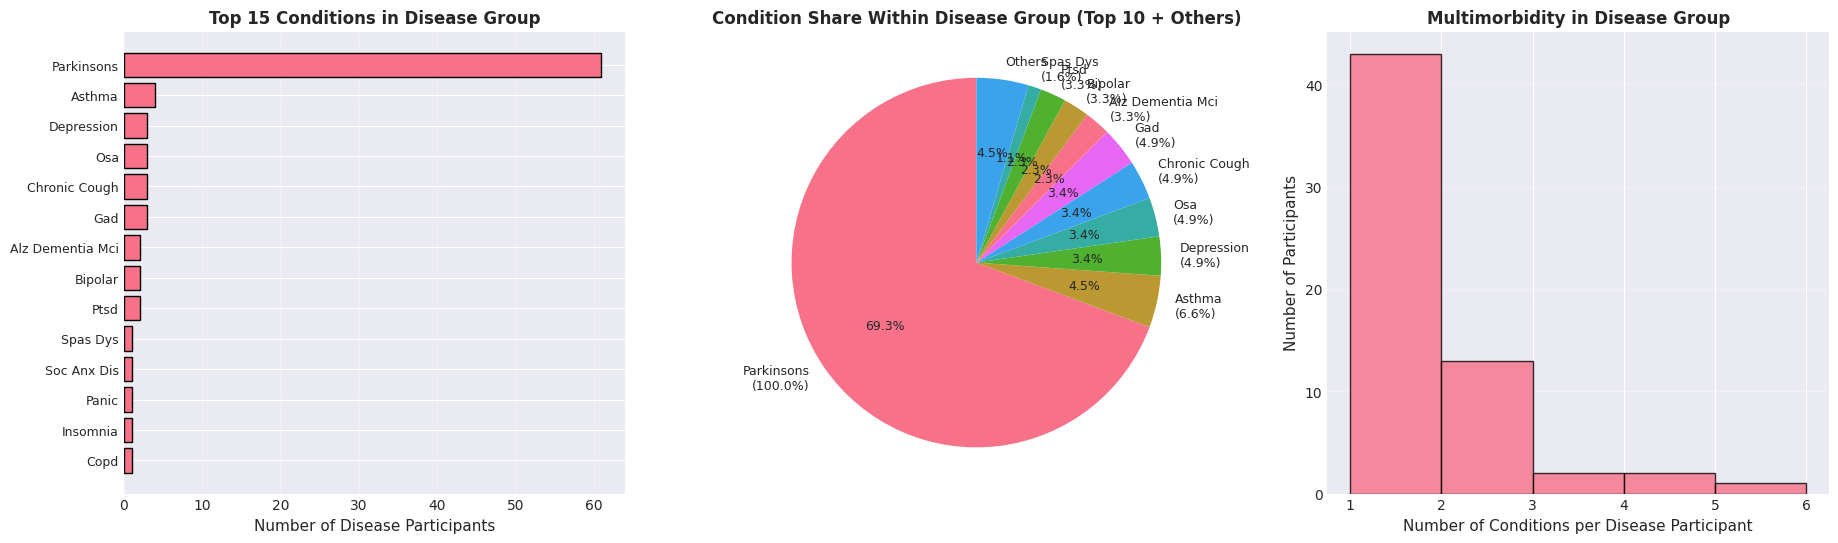

In [21]:
# ============================================
# Disease Condition Breakdown Visualization
# ============================================
print("\n" + "=" * 60)
print("Disease Condition Breakdown (by individual conditions)")
print("=" * 60)

# We assume:
# - phenotype_df has a 'label' column (0 = Normal, 1 = Disease)
# - checked_cols is the list of condition columns where 'checked' means present

disease_mask = (phenotype_df['label'] == 1)
n_disease = disease_mask.sum()
print(f"✓ Disease-labeled participants: {n_disease}")

# Count how many disease participants have each condition
condition_counts_disease = {}
for col in checked_cols:
    count = ((disease_mask) & (phenotype_df[col].astype(str).str.lower() == 'checked')).sum()
    if count > 0:
        condition_counts_disease[col] = count

condition_series_disease = (
    pd.Series(condition_counts_disease)
    .sort_values(ascending=False)
)

print(f"✓ Conditions with at least one 'checked' among Disease: {len(condition_series_disease)}")

# Convert to nicer labels + percentages
condition_names = [c.replace('_', ' ').title() for c in condition_series_disease.index]
condition_counts_vals = condition_series_disease.values
condition_pct_vals = condition_counts_vals / n_disease * 100

# ---- Plot: breakdown of disease conditions ----
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# 1) Horizontal bar chart for top 15 conditions
top_n = 15
top_counts = condition_counts_vals[:top_n]
top_names = condition_names[:top_n]
axes[0].barh(range(len(top_counts)), top_counts, edgecolor='black')
axes[0].set_yticks(range(len(top_counts)))
axes[0].set_yticklabels(top_names, fontsize=9)
axes[0].invert_yaxis()
axes[0].set_xlabel('Number of Disease Participants', fontsize=11)
axes[0].set_title(f'Top {top_n} Conditions in Disease Group', fontsize=12, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# 2) Pie chart for top 10 conditions (by prevalence among Disease)
top_n_pie = 10
pie_counts = condition_counts_vals[:top_n_pie]
pie_labels = [f"{n}\n({p:.1f}%)" for n, p in zip(condition_names[:top_n_pie],
                                                 condition_pct_vals[:top_n_pie])]
other_count = condition_counts_vals[top_n_pie:].sum()
if other_count > 0:
    pie_counts = list(pie_counts) + [other_count]
    pie_labels = pie_labels + ['Others']

axes[1].pie(
    pie_counts,
    labels=pie_labels,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 9}
)
axes[1].set_title('Condition Share Within Disease Group (Top 10 + Others)',
                  fontsize=12, fontweight='bold')

# 3) How many conditions each disease participant has
conditions_matrix = (
    phenotype_df[checked_cols]
    .astype(str)
    .apply(lambda col: col.str.lower() == 'checked')
)

n_conditions_per_patient = conditions_matrix[disease_mask].sum(axis=1)

axes[2].hist(
    n_conditions_per_patient,
    bins=range(1, int(n_conditions_per_patient.max()) + 2),
    edgecolor='black',
    alpha=0.8
)
axes[2].set_xlabel('Number of Conditions per Disease Participant', fontsize=11)
axes[2].set_ylabel('Number of Participants', fontsize=11)
axes[2].set_title('Multimorbidity in Disease Group', fontsize=12, fontweight='bold')
axes[2].grid(axis='y', alpha=0.3)


5. CONDITION ANALYSIS IN DISEASE GROUP
✓ Disease-labeled participants: 61


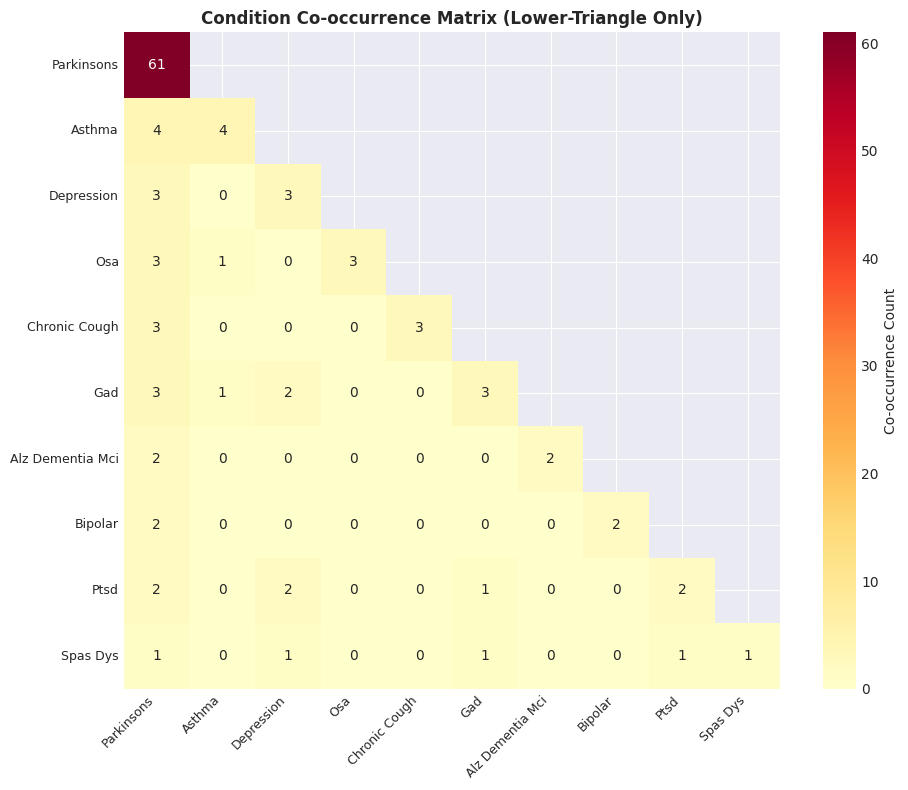

In [22]:
# 5. Top Conditions Within Disease Group (Co-occurrence Only)
print("=" * 60)
print("5. CONDITION ANALYSIS IN DISEASE GROUP")
print("=" * 60)

disease_mask = phenotype_df['label'] == 1
n_disease = disease_mask.sum()
print(f"✓ Disease-labeled participants: {n_disease}")

# Count how many disease participants have each condition
conditions_in_disease = {}
for col in checked_cols:
    col_vals = phenotype_df[col].astype(str).str.lower()
    count = ((col_vals == 'checked') & disease_mask).sum()
    if count > 0:
        conditions_in_disease[col] = count

top_conditions = (
    pd.Series(conditions_in_disease)
    .sort_values(ascending=False)
    .head(20)
)

# print("\n✓ Top conditions among Disease cases:")
# print(top_conditions)

# -----------------------------
# Condition co-occurrence heatmap (top 10)
# -----------------------------
top_10_conditions = top_conditions.head(10).index.tolist()

# Build boolean matrix
cond_matrix = (
    phenotype_df.loc[disease_mask, top_10_conditions]
    .astype(str)
    .apply(lambda col: col.str.lower() == 'checked')
    .astype(int)
)

# Co-occurrence matrix
cooccurrence = cond_matrix.T @ cond_matrix

# Pretty labels
pretty_labels = [c.replace('_', ' ').title()[:20] for c in top_10_conditions]
cooccurrence.index = pretty_labels
cooccurrence.columns = pretty_labels

# -----------------------------
# Mask upper triangle
# -----------------------------
mask = np.triu(np.ones_like(cooccurrence, dtype=bool), k=1)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cooccurrence,
    annot=True,
    fmt='d',
    cmap='YlOrRd',
    mask=mask,                # <<< ONLY LOWER HALF SHOWN
    cbar_kws={'label': 'Co-occurrence Count'},
    square=True
)

plt.title('Condition Co-occurrence Matrix (Lower-Triangle Only)', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'disease_condition_cooccurrence_lower_triangle.png', dpi=300, bbox_inches='tight')
plt.show()


6. VOICE EXERCISES/TASKS ANALYSIS
✓ Found 53 unique voice exercises/tasks
  Total recordings: 19271

📊 Task Distribution:
  - Most common task: Audio-Check-1 (554 recordings)
  - Least common task: Animal-fluency (95 recordings)


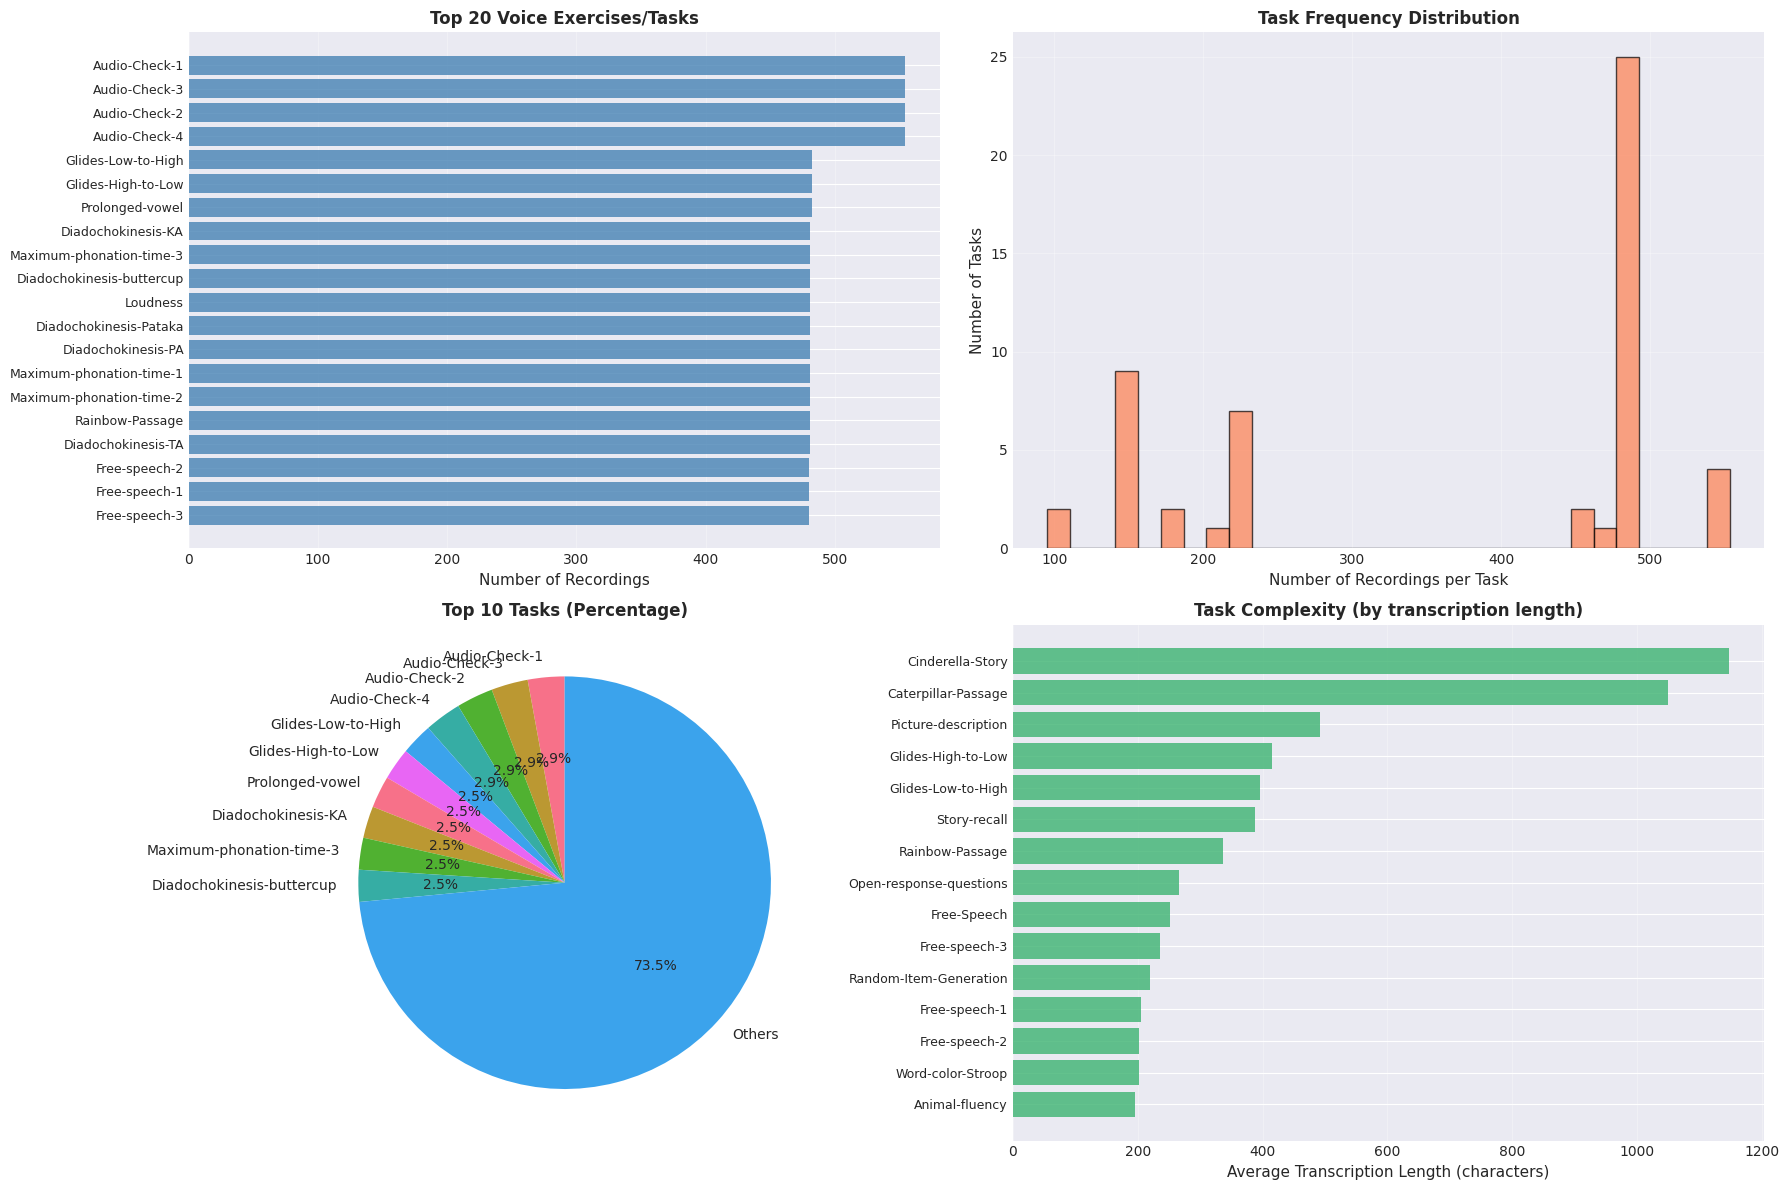


📝 Common Voice Exercises in Dataset:
  • Audio-Check-1: General voice/speech assessment task (554 recordings)
  • Audio-Check-3: General voice/speech assessment task (554 recordings)
  • Audio-Check-2: General voice/speech assessment task (554 recordings)
  • Audio-Check-4: General voice/speech assessment task (554 recordings)
  • Glides-Low-to-High: General voice/speech assessment task (482 recordings)
  • Glides-High-to-Low: General voice/speech assessment task (482 recordings)
  • Prolonged-vowel: General voice/speech assessment task (482 recordings)
  • Diadochokinesis-KA: Rapid syllable repetition (e.g., "pa-ta-ka") - tests motor speech coordination (481 recordings)
  • Maximum-phonation-time-3: General voice/speech assessment task (481 recordings)
  • Diadochokinesis-buttercup: Rapid syllable repetition (e.g., "pa-ta-ka") - tests motor speech coordination (481 recordings)

✓ Task summary saved to: /home/Phenotype and Voice for PD/outputs/eda_phase_2/task_summary.csv


In [23]:
# 6. Voice Exercises/Tasks Analysis
print("=" * 60)
print("6. VOICE EXERCISES/TASKS ANALYSIS")
print("=" * 60)

# Load static features to get task information
if STATIC_FILE.exists():
    static_df = pd.read_csv(STATIC_FILE, sep='\t', low_memory=False)
    
    # Analyze task names if available
    if 'task_name' in static_df.columns:
        task_counts = static_df['task_name'].value_counts()
        print(f"✓ Found {len(task_counts)} unique voice exercises/tasks")
        print(f"  Total recordings: {len(static_df)}")
        
        # Task distribution
        print(f"\n📊 Task Distribution:")
        print(f"  - Most common task: {task_counts.index[0]} ({task_counts.iloc[0]} recordings)")
        print(f"  - Least common task: {task_counts.index[-1]} ({task_counts.iloc[-1]} recordings)")
        
        # Visualize task distribution
        fig, axes = plt.subplots(2, 2, figsize=(18, 12))
        
        # Top 20 tasks
        top_tasks = task_counts.head(20)
        axes[0, 0].barh(range(len(top_tasks)), top_tasks.values, color='steelblue', alpha=0.8)
        axes[0, 0].set_yticks(range(len(top_tasks)))
        axes[0, 0].set_yticklabels([str(t)[:40] for t in top_tasks.index], fontsize=9)
        axes[0, 0].invert_yaxis()
        axes[0, 0].set_xlabel('Number of Recordings', fontsize=11)
        axes[0, 0].set_title('Top 20 Voice Exercises/Tasks', fontsize=12, fontweight='bold')
        axes[0, 0].grid(axis='x', alpha=0.3)
        
        # Task frequency distribution
        axes[0, 1].hist(task_counts.values, bins=30, color='coral', edgecolor='black', alpha=0.7)
        axes[0, 1].set_xlabel('Number of Recordings per Task', fontsize=11)
        axes[0, 1].set_ylabel('Number of Tasks', fontsize=11)
        axes[0, 1].set_title('Task Frequency Distribution', fontsize=12, fontweight='bold')
        axes[0, 1].grid(alpha=0.3)
        
        # Pie chart for top 10 tasks
        top_10_tasks = task_counts.head(10)
        other_count = task_counts.iloc[10:].sum()
        pie_data = list(top_10_tasks.values) + [other_count]
        pie_labels = [str(t)[:30] for t in top_10_tasks.index] + ['Others']
        axes[1, 0].pie(pie_data, labels=pie_labels, autopct='%1.1f%%', startangle=90)
        axes[1, 0].set_title('Top 10 Tasks (Percentage)', fontsize=12, fontweight='bold')
        
        # Task length analysis (if transcription available)
        if 'transcription' in static_df.columns:
            static_df['transcription_length'] = static_df['transcription'].astype(str).str.len()
            task_lengths = static_df.groupby('task_name')['transcription_length'].mean().sort_values(ascending=False).head(15)
            axes[1, 1].barh(range(len(task_lengths)), task_lengths.values, color='mediumseagreen', alpha=0.8)
            axes[1, 1].set_yticks(range(len(task_lengths)))
            axes[1, 1].set_yticklabels([str(t)[:30] for t in task_lengths.index], fontsize=9)
            axes[1, 1].invert_yaxis()
            axes[1, 1].set_xlabel('Average Transcription Length (characters)', fontsize=11)
            axes[1, 1].set_title('Task Complexity (by transcription length)', fontsize=12, fontweight='bold')
            axes[1, 1].grid(axis='x', alpha=0.3)
        else:
            axes[1, 1].text(0.5, 0.5, 'Transcription data not available', 
                           ha='center', va='center', fontsize=12, transform=axes[1, 1].transAxes)
            axes[1, 1].set_title('Task Complexity', fontsize=12, fontweight='bold')
        
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / 'voice_exercises_analysis.png', dpi=150, bbox_inches='tight')
        plt.show()
        
        # Task descriptions (common voice exercises)
        print(f"\n📝 Common Voice Exercises in Dataset:")
        task_descriptions = {
            'sustained_vowel': 'Sustained vowel production (e.g., "ah", "ee") - tests phonation stability',
            'reading_passage': 'Reading standardized passages - tests connected speech and articulation',
            'diadochokinesis': 'Rapid syllable repetition (e.g., "pa-ta-ka") - tests motor speech coordination',
            'monologue': 'Spontaneous speech or conversation - tests natural speech production',
            'pitch_variation': 'Varying pitch patterns - tests prosodic control',
            'breath_control': 'Breathing exercises - tests respiratory support for speech'
        }
        
        for task_name in task_counts.head(10).index:
            task_str = str(task_name).lower()
            description = "General voice/speech assessment task"
            for key, desc in task_descriptions.items():
                if key in task_str:
                    description = desc
                    break
            print(f"  • {task_name}: {description} ({task_counts[task_name]} recordings)")
        
        # Save task summary
        task_summary = pd.DataFrame({
            'task_name': task_counts.index,
            'count': task_counts.values,
            'percentage': (task_counts.values / len(static_df) * 100).round(2)
        })
        task_summary.to_csv(OUTPUT_DIR / 'task_summary.csv', index=False)
        print(f"\n✓ Task summary saved to: {OUTPUT_DIR / 'task_summary.csv'}")
        
    else:
        print("⚠ 'task_name' column not found in static features")
        task_counts = pd.Series()
else:
    print("⚠ Static features file not found - cannot analyze tasks")
    task_counts = pd.Series()


In [24]:
# Identify the patient/participant column
PATIENT_COL = "participant_id"   # <-- update if needed

# 6b. Sample transcriptions for ALL tasks
print("\n" + "=" * 60)
print("6b. SAMPLE TRANSCRIPTIONS FOR ALL TASKS")
print("=" * 60)

if "transcription" not in static_df.columns:
    print("⚠ 'transcription' column not found in static_df — cannot show examples.")
else:
    n_examples_per_task = 3  # change if needed

    for task_name in task_counts.index:   # ALL tasks
        subset = static_df[static_df["task_name"] == task_name]

        if subset.empty:
            continue

        print(f"\n--- Task: {task_name} ({len(subset)} recordings) ---")

        # Sample rows
        examples = subset.sample(
            n=min(n_examples_per_task, len(subset)),
            random_state=0
        )

        for _, row in examples.iterrows():
            # Safe patient ID retrieval
            if PATIENT_COL in row:
                pid_str = f"{PATIENT_COL}={row[PATIENT_COL]}"
            else:
                pid_str = "patient=NA"

            text = str(row["transcription"])
            short_text = (text[:160] + "…") if len(text) > 160 else text

            print(f"  • {pid_str}: {short_text}")



6b. SAMPLE TRANSCRIPTIONS FOR ALL TASKS

--- Task: Audio-Check-1 (554 recordings) ---
  • participant_id=26d28fe1: Testing one, two, three.
  • participant_id=3647afc1: Testing 1, 2, 3.
  • participant_id=28cc3eda: Testing, testing, one, two, three.

--- Task: Audio-Check-3 (554 recordings) ---
  • participant_id=26d28fe1: Oh, oh, oh, oh, oh, oh, oh, oh, oh, oh, oh, oh, oh, oh, oh, oh, oh, oh, oh, oh, oh, oh, oh, oh, oh, oh, oh, oh, oh, oh, oh, oh, oh, oh, oh, oh, oh, oh, oh, oh, …
  • participant_id=3647afc1: Oh, my God.
  • participant_id=28cc3eda: Ahem. Ahem. Ahem. Ahem.

--- Task: Audio-Check-2 (554 recordings) ---
  • participant_id=26d28fe1: I am happy to participate in the Bridge to A1 study.
  • participant_id=3647afc1: I am happy to participate in the Bridge to AI study.
  • participant_id=28cc3eda: I am happy to participate in the Bridge to AI study.

--- Task: Audio-Check-4 (554 recordings) ---
  • participant_id=26d28fe1: .
  • participant_id=3647afc1: I'm going to go to t

In [25]:
# 7. Static Acoustic Features Analysis (Summary Only)
print("=" * 60)
print("7. STATIC ACOUSTIC FEATURES ANALYSIS")
print("=" * 60)

if STATIC_FILE.exists():
    static_df = pd.read_csv(STATIC_FILE, sep='\t', low_memory=False)
    print(f"✓ Static features shape: {static_df.shape}")
    print(f"  - Recordings: {static_df.shape[0]}")
    print(f"  - Features: {static_df.shape[1]}")
    
    # Identify feature types
    numeric_cols = static_df.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = static_df.select_dtypes(include=['object']).columns.tolist()
    id_cols = ['participant_id', 'session_id', 'task_name', 'transcription']
    
    feature_cols = [c for c in numeric_cols if c not in id_cols]
    print(f"\nFeature breakdown:")
    print(f"  - Numeric features (used for modeling): {len(feature_cols)}")
    print(f"  - Categorical columns: {len([c for c in categorical_cols if c not in id_cols])}")
    print(f"  - ID/metadata columns: {len([c for c in id_cols if c in static_df.columns])}")
    
    # Simple plain-language description
    print("\nSimple description of these features:")
    print("  • Static acoustic features: numbers that summarize each recording as a whole")
    print("    (e.g., averages, variability, and extremes of different voice properties).")
    print("  • MFCC features: describe how the energy in the voice is distributed across")
    print("    frequencies; they are a compact representation of the voice timbre and")
    print("    are widely used in speech and speaker recognition.")
    
    # Feature categories
    mfcc_features = [f for f in feature_cols if 'mfcc' in f.lower()]
    prosody_features = [f for f in feature_cols if any(x in f.lower() for x in ['f0', 'pitch', 'jitter', 'shimmer', 'hnr'])]
    formant_features = [f for f in feature_cols if any(x in f.lower() for x in ['f1', 'f2', 'f3', 'formant'])]
    energy_features = [f for f in feature_cols if 'energy' in f.lower() or 'loudness' in f.lower()]
    other_features = [f for f in feature_cols if f not in mfcc_features + prosody_features + formant_features + energy_features]
    
    print(f"\nFeature categories (by name pattern):")
    print(f"  - MFCC features: {len(mfcc_features)}")
    print(f"  - Prosody features (F0, jitter, shimmer, etc.): {len(prosody_features)}")
    print(f"  - Formant features (F1, F2, F3, 'formant'): {len(formant_features)}")
    print(f"  - Energy features (energy, loudness): {len(energy_features)}")
    print(f"  - Other features: {len(other_features)}")
    
    # Display feature NAME lists
    from IPython.display import display
    
    print("\nExample feature names in each category (up to 10 each):")
    summary_rows = [
        {
            "Category": "MFCC",
            "Count": len(mfcc_features),
            "Example features": ", ".join(mfcc_features[:10])
        },
        {
            "Category": "Prosody (F0, jitter, shimmer)",
            "Count": len(prosody_features),
            "Example features": ", ".join(prosody_features[:10])
        },
        {
            "Category": "Formant",
            "Count": len(formant_features),
            "Example features": ", ".join(formant_features[:10])
        },
        {
            "Category": "Energy / Loudness",
            "Count": len(energy_features),
            "Example features": ", ".join(energy_features[:10])
        },
        {
            "Category": "Other",
            "Count": len(other_features),
            "Example features": ", ".join(other_features[:10])
        },
    ]
    
    feature_overview_df = pd.DataFrame(summary_rows)
    display(feature_overview_df)

else:
    raise FileNotFoundError(f'static_features.tsv not found at {STATIC_FILE}')


7. STATIC ACOUSTIC FEATURES ANALYSIS
✓ Static features shape: (19271, 135)
  - Recordings: 19271
  - Features: 135

Feature breakdown:
  - Numeric features (used for modeling): 131
  - Categorical columns: 0
  - ID/metadata columns: 4

Simple description of these features:
  • Static acoustic features: numbers that summarize each recording as a whole
    (e.g., averages, variability, and extremes of different voice properties).
  • MFCC features: describe how the energy in the voice is distributed across
    frequencies; they are a compact representation of the voice timbre and
    are widely used in speech and speaker recognition.

Feature categories (by name pattern):
  - MFCC features: 16
  - Prosody features (F0, jitter, shimmer, etc.): 41
  - Formant features (F1, F2, F3, 'formant'): 22
  - Energy features (energy, loudness): 11
  - Other features: 47

Example feature names in each category (up to 10 each):


,Category,Count,Example features
0,MFCC,16,"mfcc1_sma3_amean, mfcc1_sma3_stddevNorm, mfcc2..."
1,"Prosody (F0, jitter, shimmer)",41,"F0semitoneFrom27.5Hz_sma3nz_amean, F0semitoneF..."
2,Formant,22,"F1frequency_sma3nz_amean, F1frequency_sma3nz_s..."
3,Energy / Loudness,11,"loudness_sma3_amean, loudness_sma3_stddevNorm,..."
4,Other,47,"spectralFlux_sma3_amean, spectralFlux_sma3_std..."


7. STATIC ACOUSTIC FEATURES ANALYSIS
✓ Static features shape: (19271, 135)
  - Recordings: 19271
  - Features: 135

Feature breakdown:
  - Numeric features: 131
  - Categorical columns: 0
  - ID/metadata columns: 4

Feature categories:
  - MFCC features: 16
  - Prosody features (F0, jitter, shimmer, etc.): 41
  - Formant features (F1, F2, F3, 'formant'): 22
  - Energy features: 11
  - Other features: 47


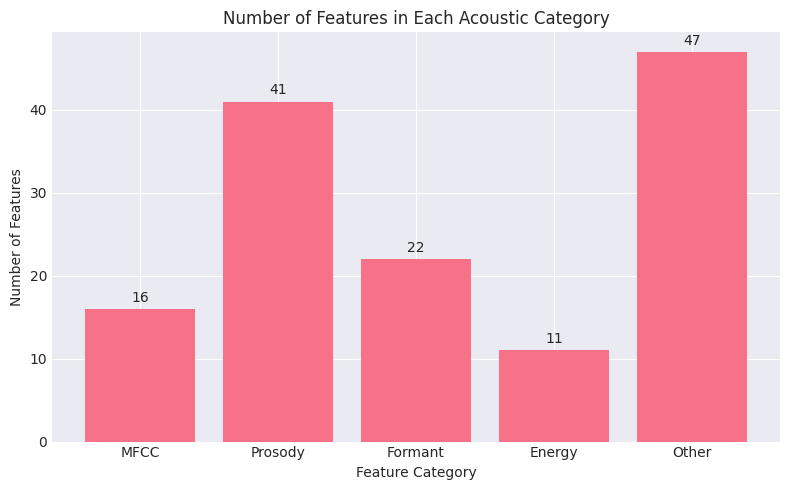


=== MFCC features: 16 total ===


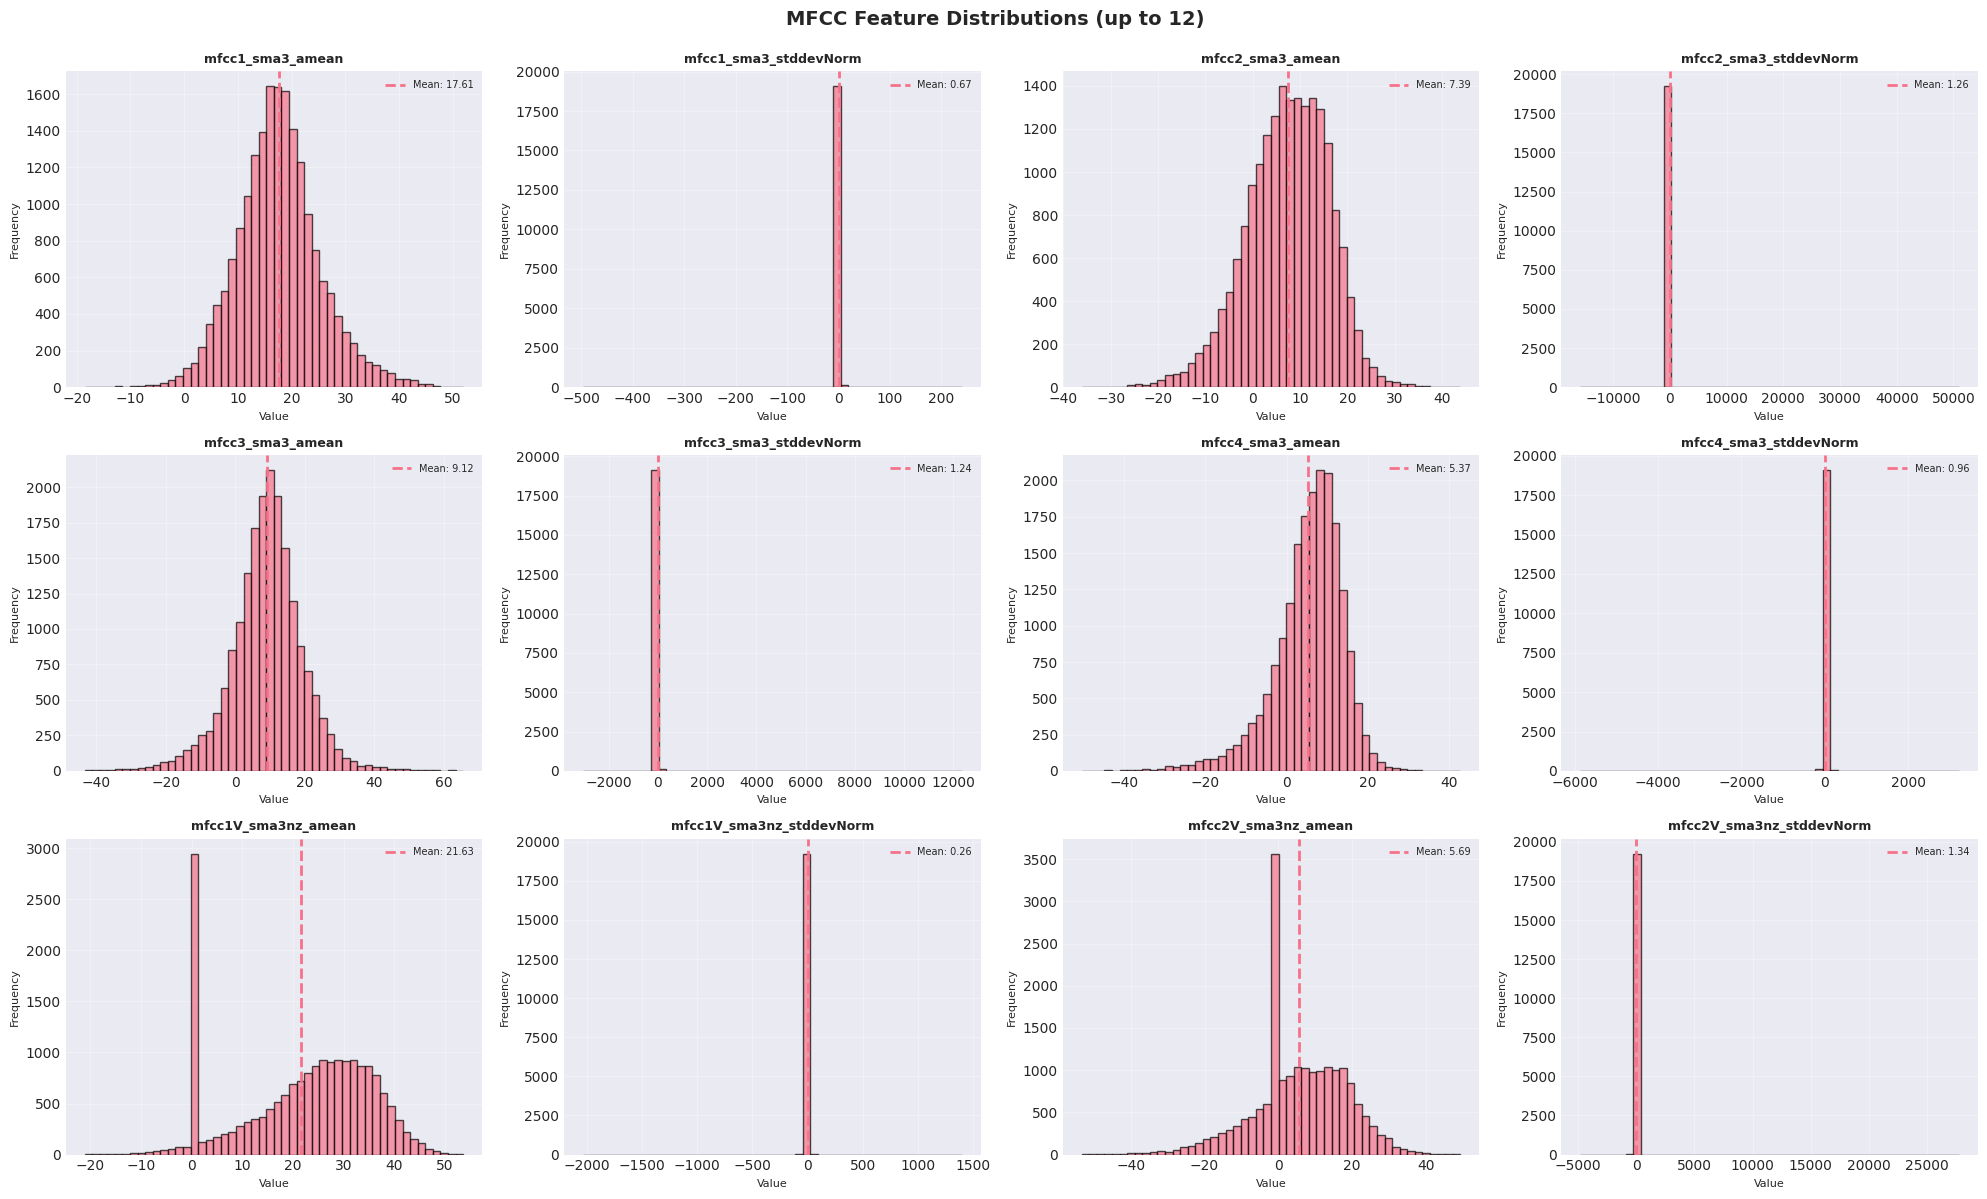


=== Prosody features: 41 total ===


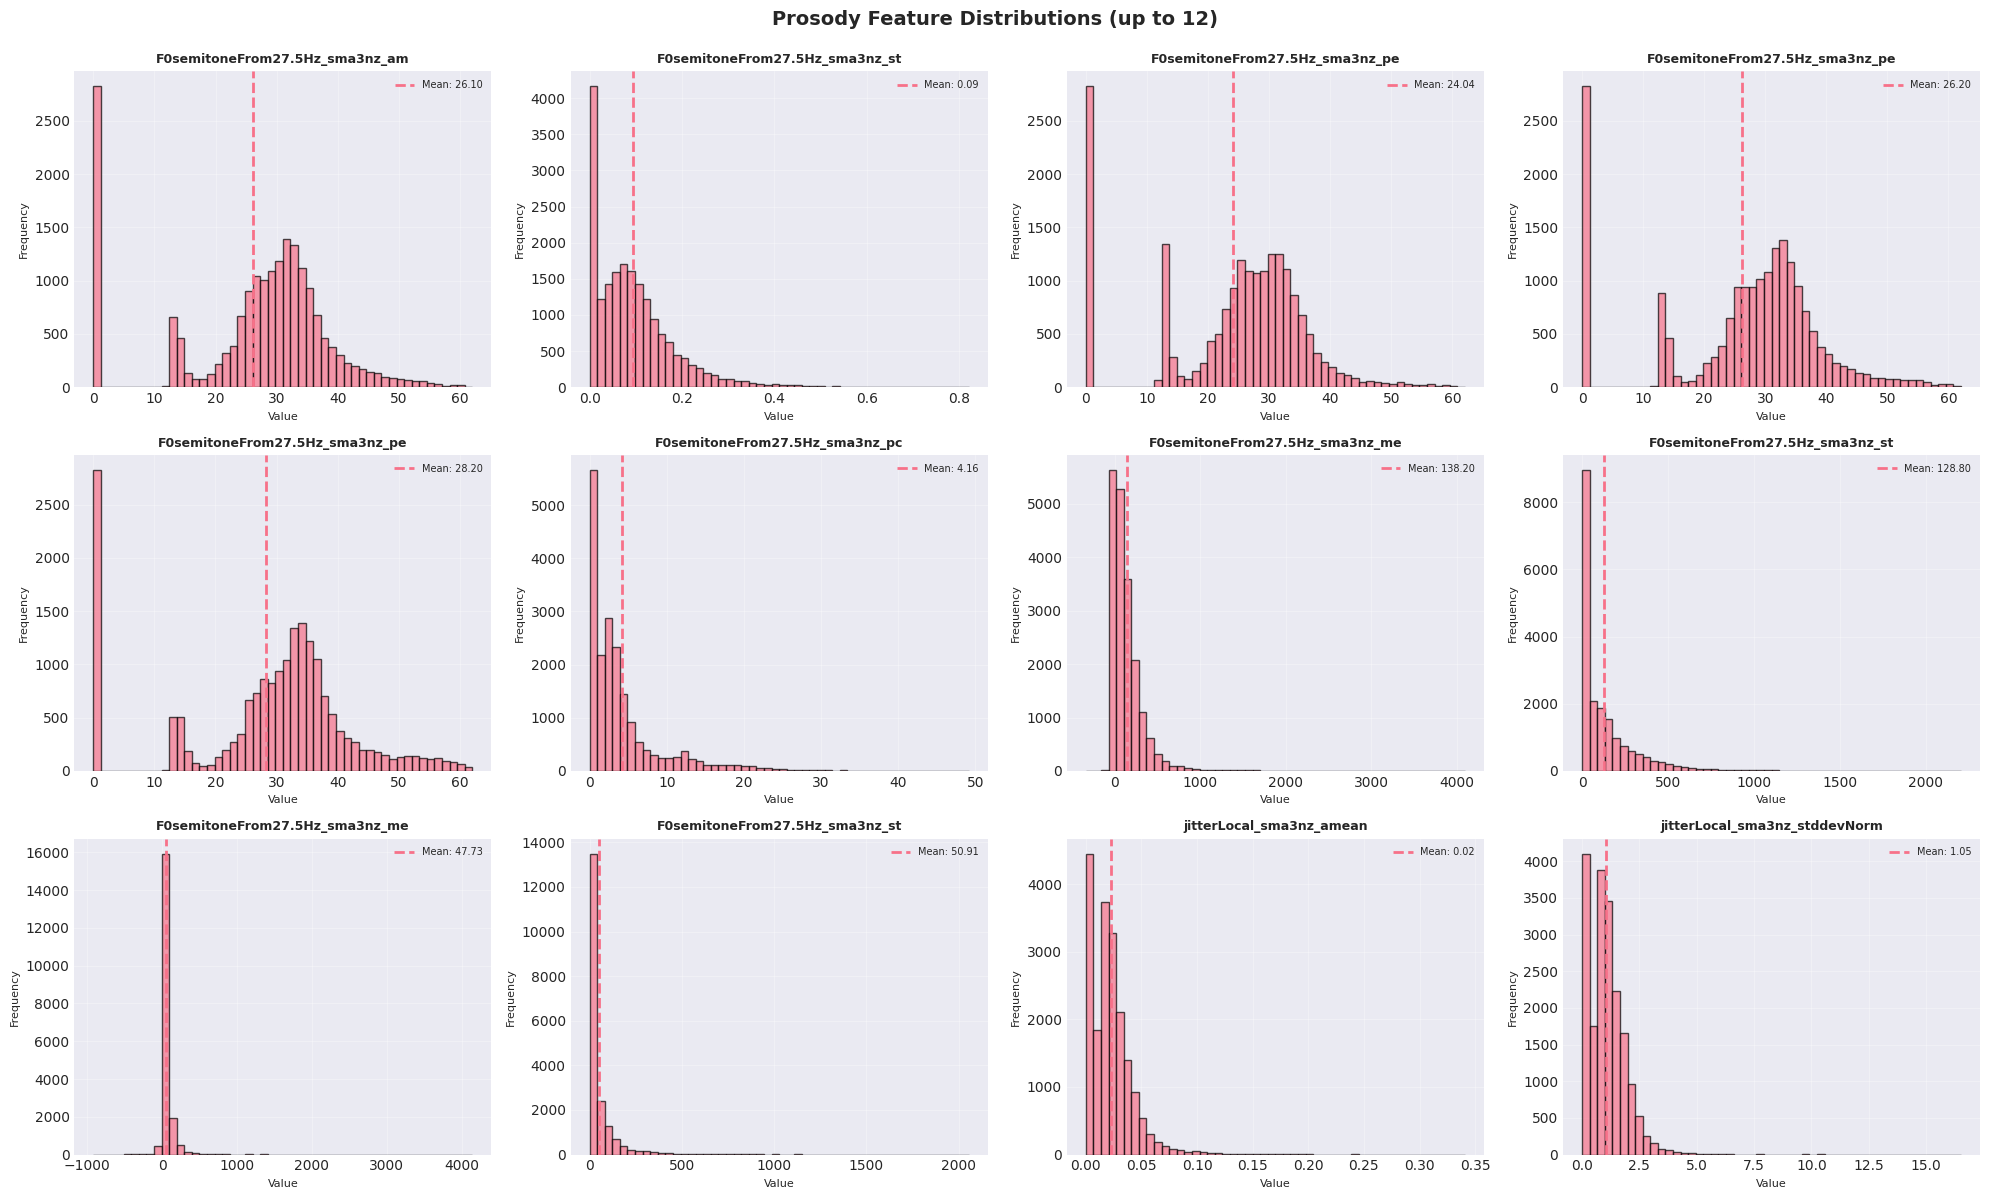


=== Formant features: 22 total ===


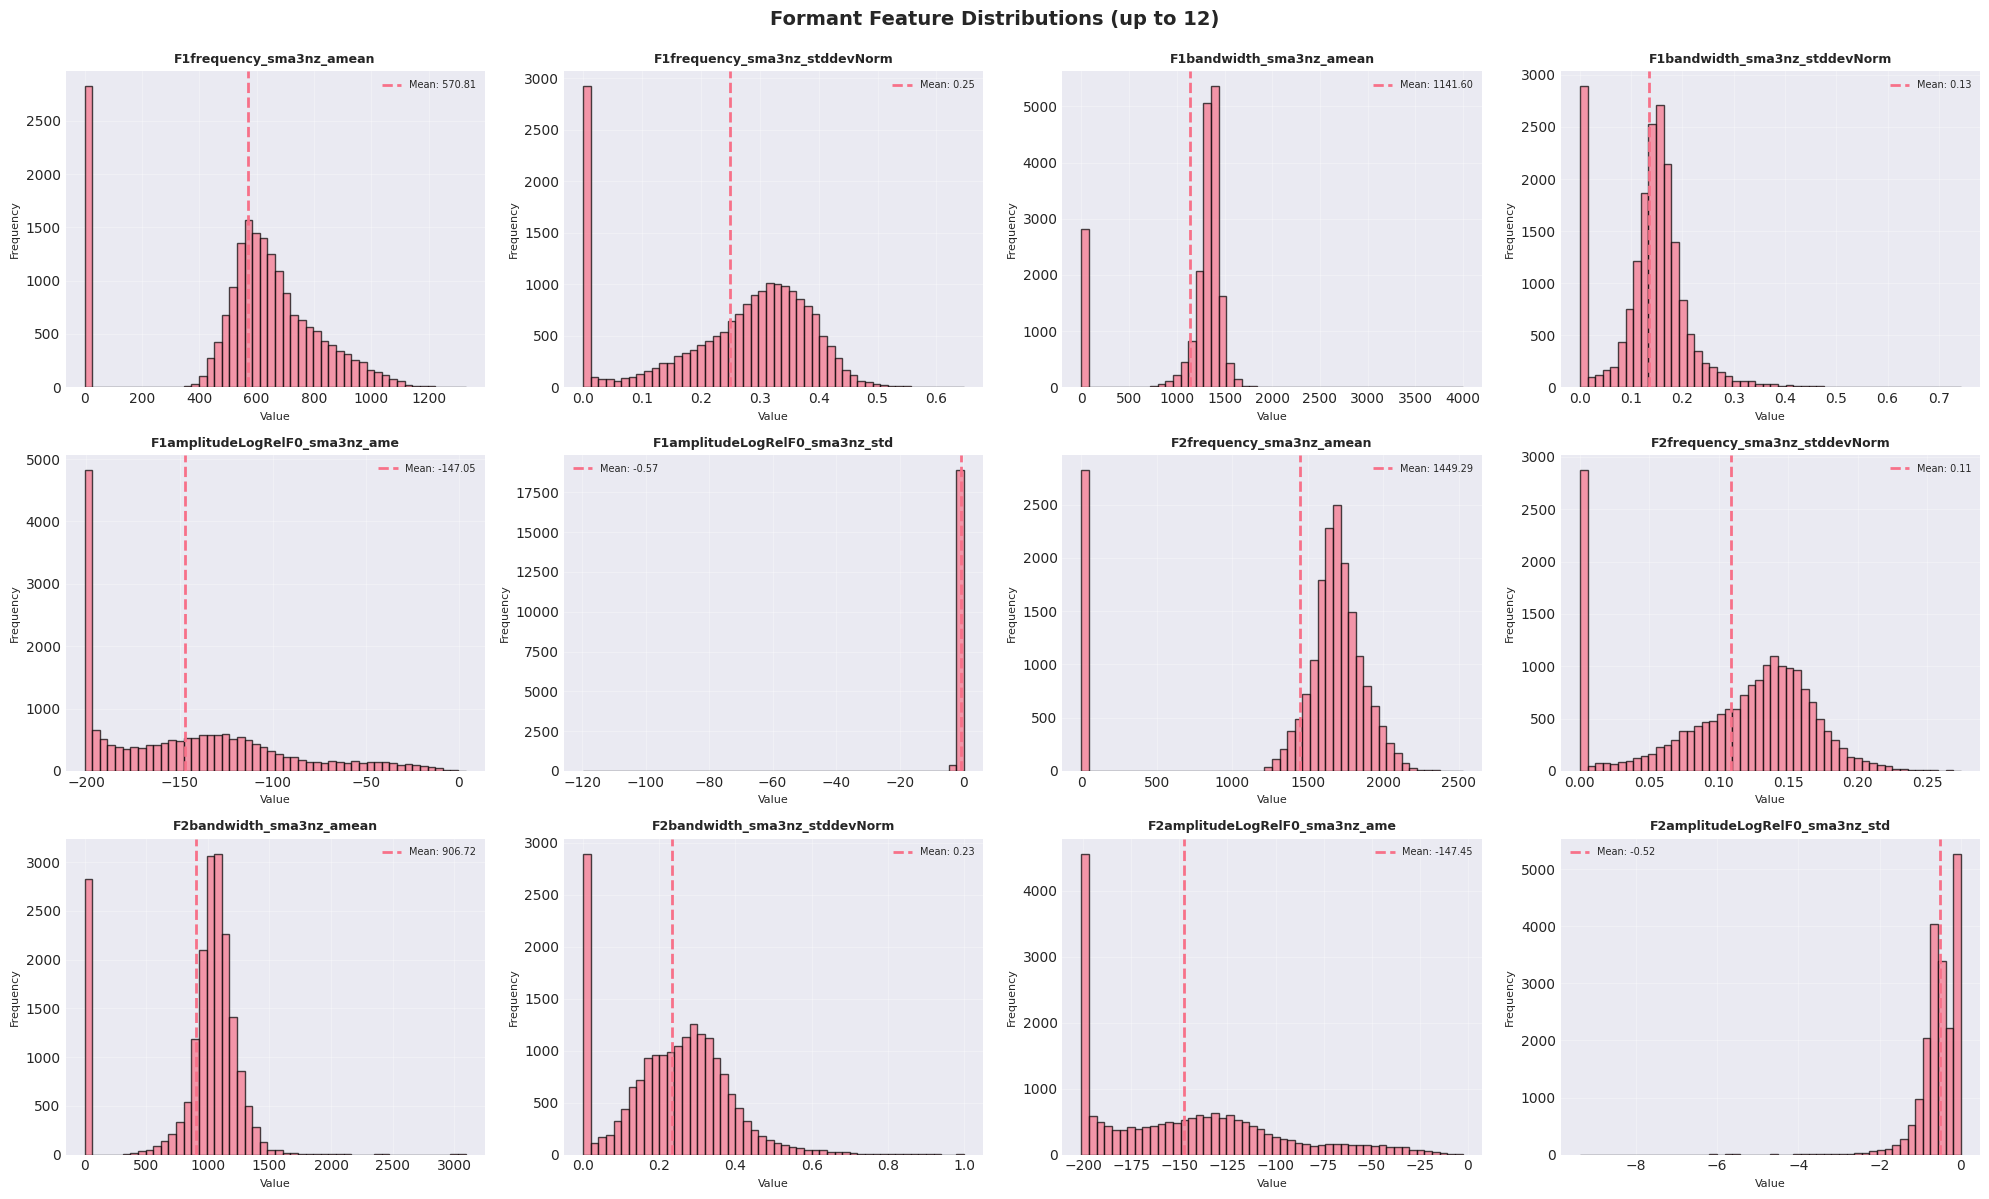


=== Energy features: 11 total ===


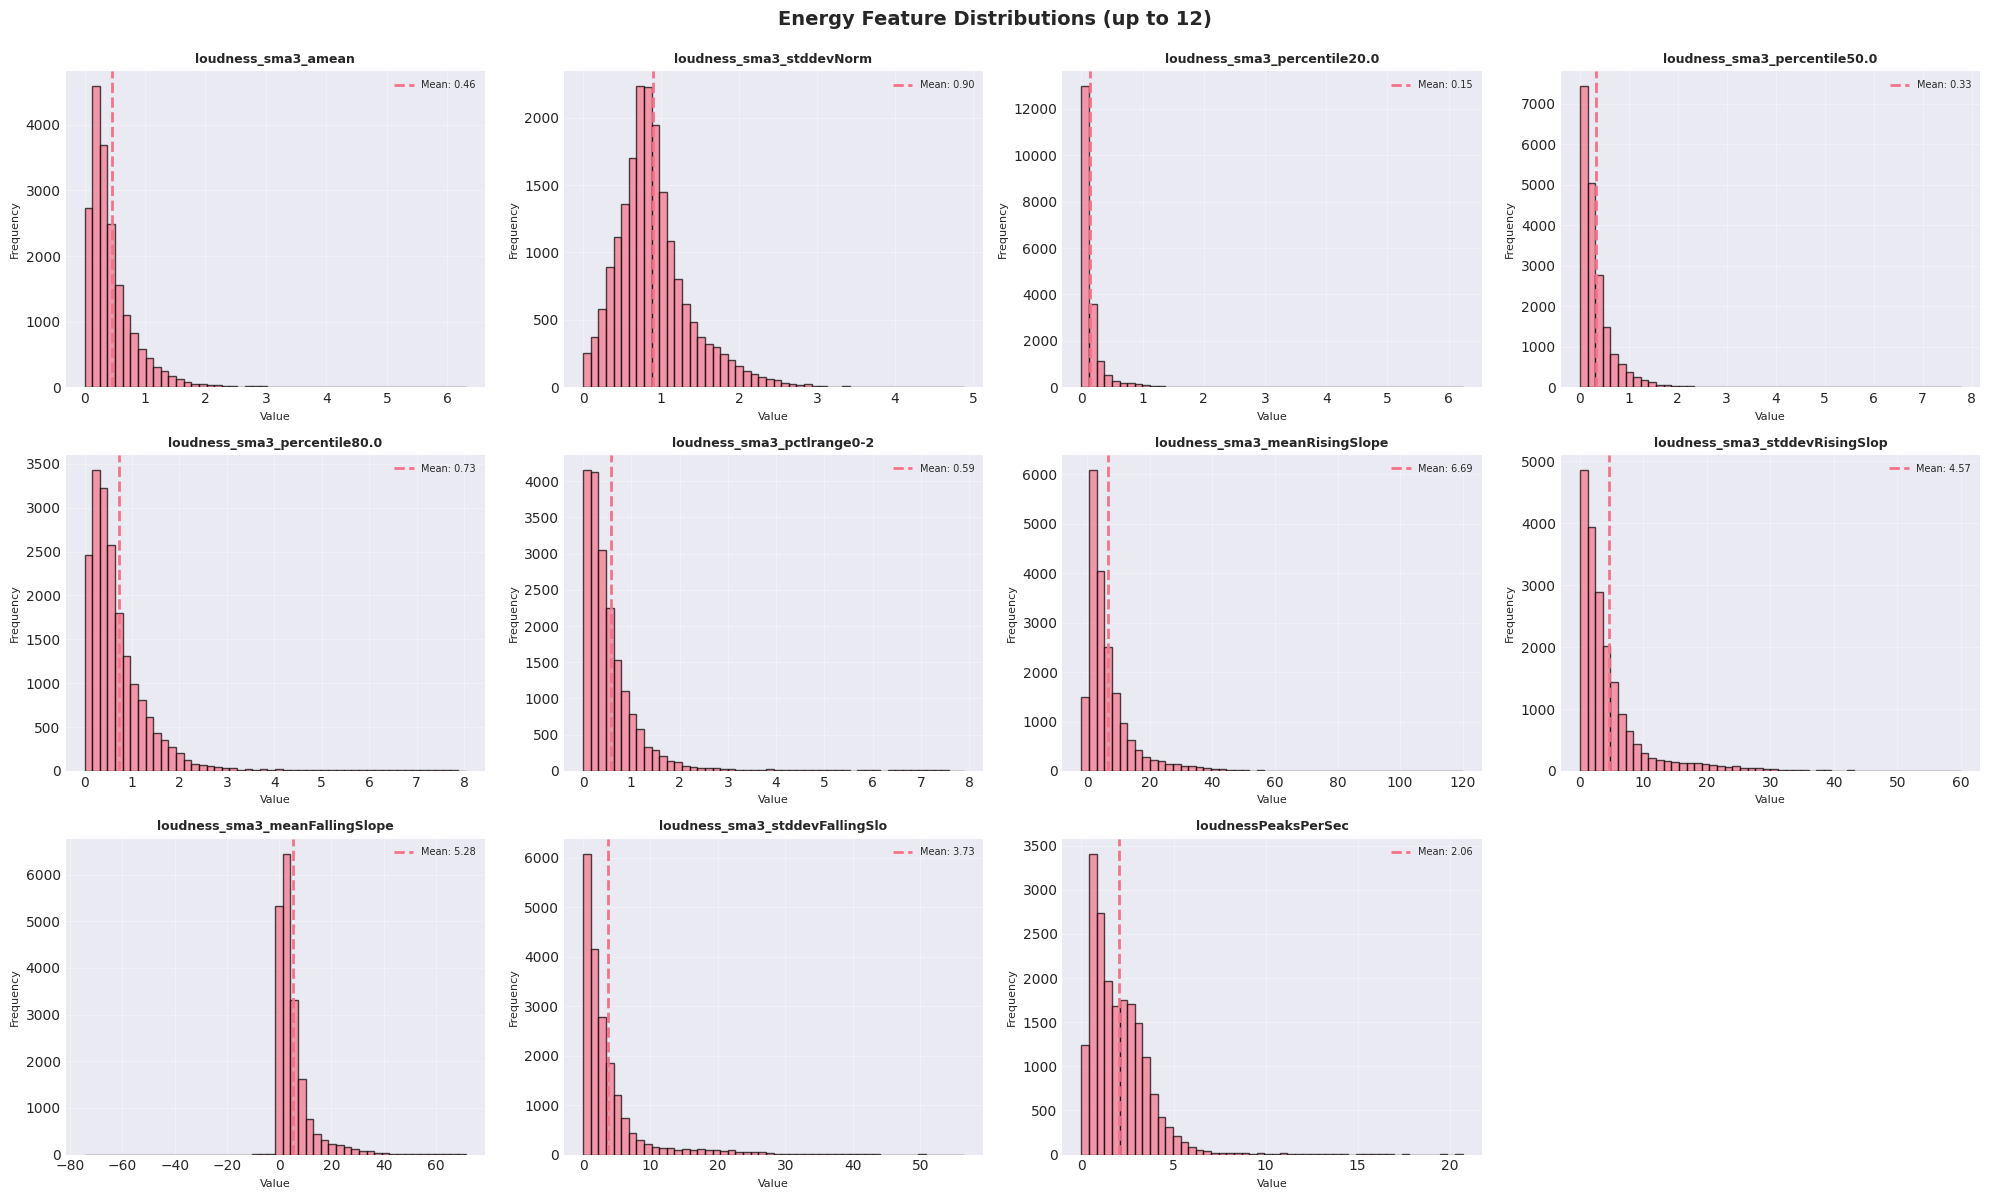


=== Other features: 47 total ===


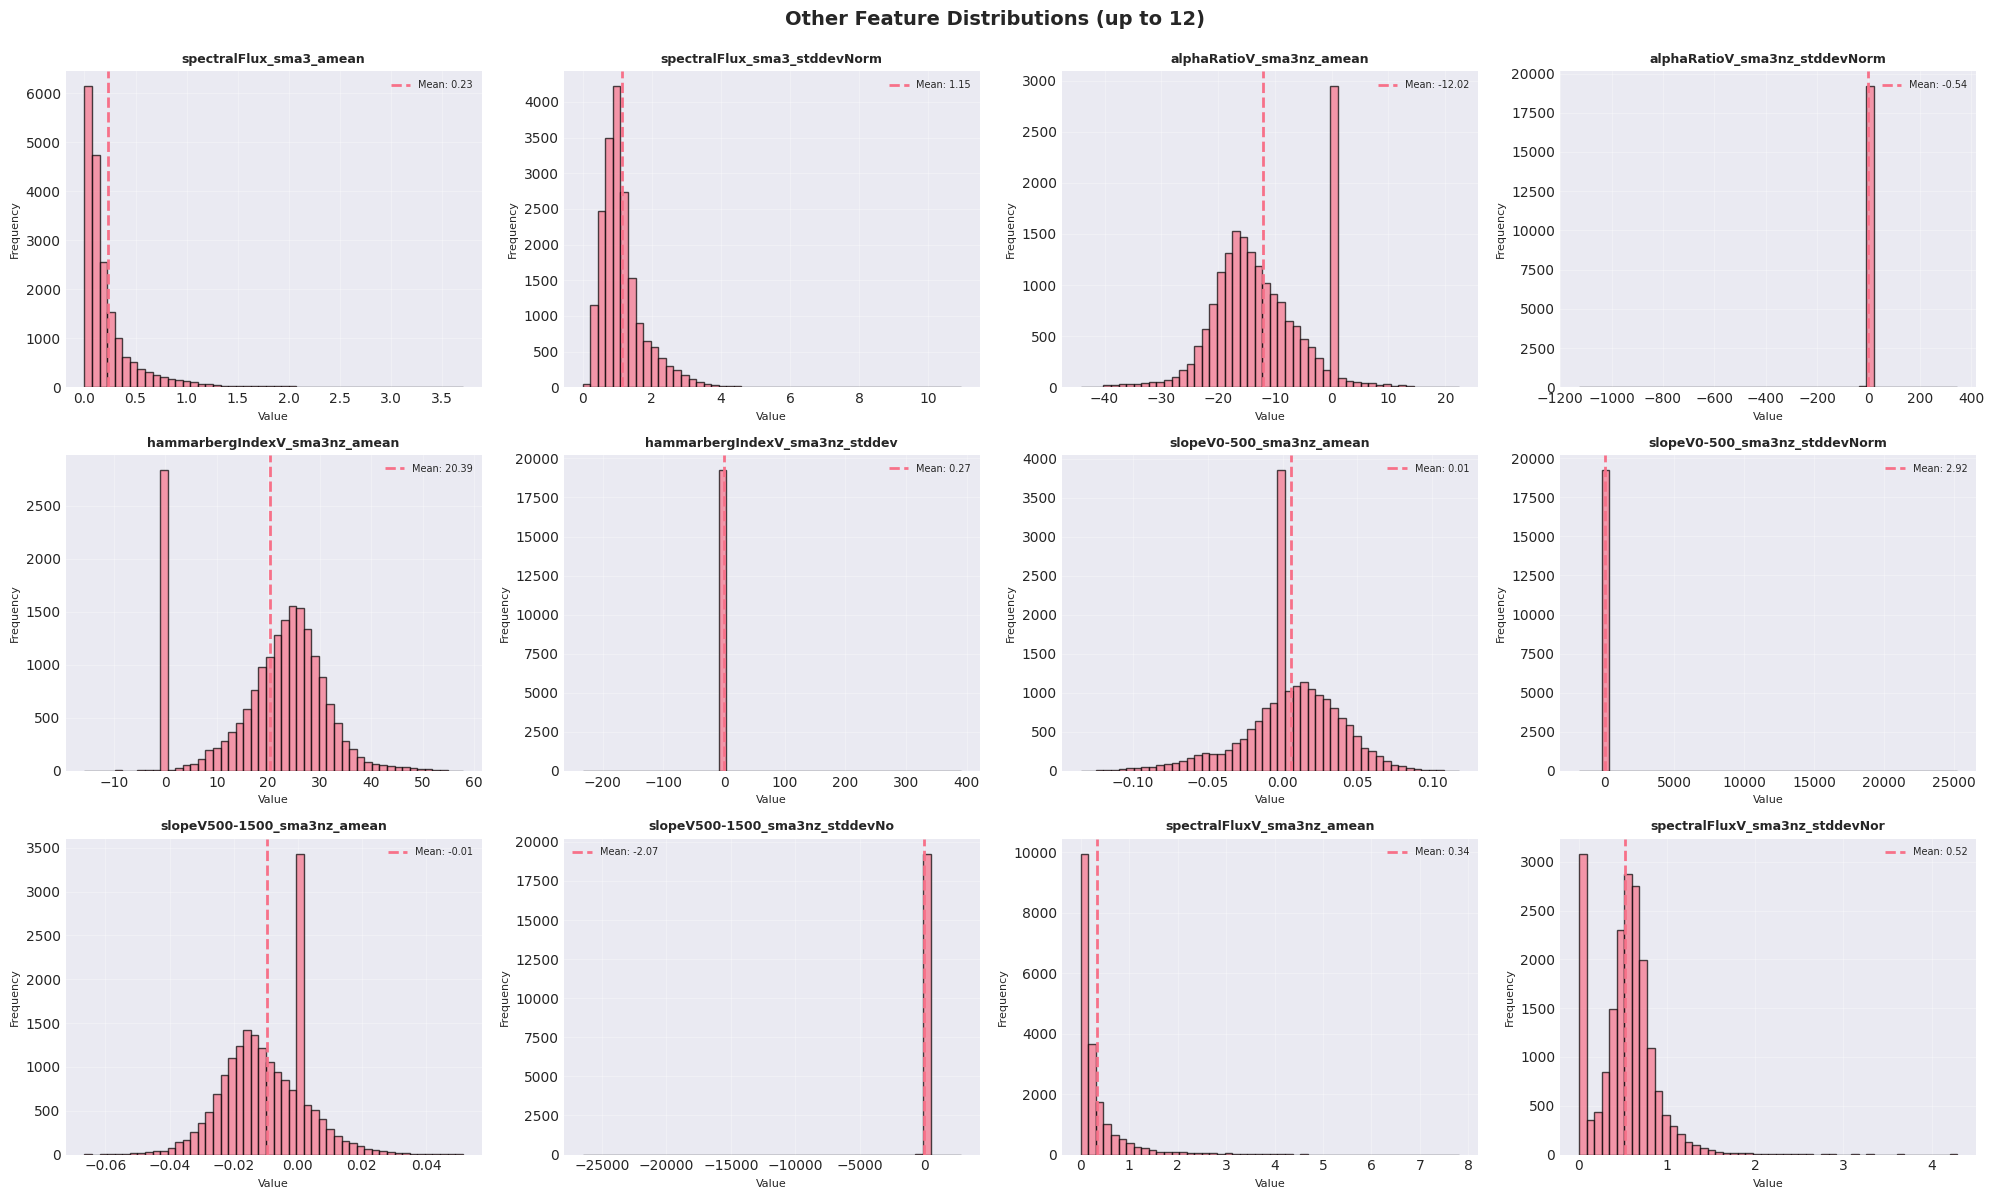


✓ Feature statistics computed

Sample statistics (first 5 features):


,count,mean,std,min,25%,50%,75%,max
F0semitoneFrom27.5Hz_sma3nz_amean,19271.0,26.101295,13.225603,0.0,21.950951,29.346601,34.057995,62.058083
F0semitoneFrom27.5Hz_sma3nz_stddevNorm,19271.0,0.094062,0.090613,0.0,0.025171,0.077657,0.132582,0.820449
F0semitoneFrom27.5Hz_sma3nz_percentile20.0,19271.0,24.036883,12.414680,0.0,18.372719,26.932673,32.091736,62.048279
F0semitoneFrom27.5Hz_sma3nz_percentile50.0,19271.0,26.197125,13.489960,0.0,21.446390,29.470922,34.314491,62.060246
F0semitoneFrom27.5Hz_sma3nz_percentile80.0,19271.0,28.197189,14.580775,0.0,23.765363,31.659206,36.336649,62.079681



✓ Merged dataset shape: (4879, 136)
  - After merge: 4879 recordings
  - Features: 136

Label distribution in merged data:
  - Control (0): 2438 (50.0%)
  - Parkinsons (1): 2441 (50.0%)


,participant_id,session_id,task_name,transcription,F0semitoneFrom27.5Hz_sma3nz_amean,F0semitoneFrom27.5Hz_sma3nz_stddevNorm,F0semitoneFrom27.5Hz_sma3nz_percentile20.0,F0semitoneFrom27.5Hz_sma3nz_percentile50.0,F0semitoneFrom27.5Hz_sma3nz_percentile80.0,F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2,...,local_shimmer,localDB_shimmer,apq3_shimmer,apq5_shimmer,apq11_shimmer,dda_shimmer,stoi,pesq,si_sdr,label
303,02955d67,148783B7,Audio-Check-1,"Testing 1, 2, 3.",31.729406,0.085532,29.780025,32.148739,34.178699,4.398674,...,0.053454,0.565522,0.024000,0.033661,0.053617,0.071999,0.990999,3.067839,24.216118,0
304,02955d67,148783B7,Audio-Check-2,I'm happy to participate in this study.,30.458693,0.072632,28.118006,30.644386,32.407879,4.289873,...,0.084955,0.829790,0.030153,0.038448,0.058320,0.090458,0.997092,3.736818,24.663988,0
305,02955d67,148783B7,Audio-Check-3,One more time.,35.526707,0.138883,33.030918,36.328392,40.151134,7.120216,...,0.154929,1.466442,0.047004,0.066841,0.142776,0.141012,0.938806,2.435746,13.192985,0
306,02955d67,148783B7,Audio-Check-4,.,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.213338,1.807084,0.073026,0.118522,NaN,0.219078,0.390597,1.128204,-16.012775,0
307,02955d67,148783B7,Cape-V-sentences-1,The blue spot is on the key again.,32.447876,0.128544,27.115948,33.605389,36.499023,9.383076,...,0.074784,0.772140,0.025133,0.033954,0.082311,0.075399,0.997519,3.626440,27.751123,0


In [26]:
# 7. Static Acoustic Features Analysis
print("=" * 60)
print("7. STATIC ACOUSTIC FEATURES ANALYSIS")
print("=" * 60)

if STATIC_FILE.exists():
    static_df = pd.read_csv(STATIC_FILE, sep='\t', low_memory=False)
    print(f"✓ Static features shape: {static_df.shape}")
    print(f"  - Recordings: {static_df.shape[0]}")
    print(f"  - Features: {static_df.shape[1]}")
    
    # Identify feature types
    numeric_cols = static_df.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = static_df.select_dtypes(include=['object']).columns.tolist()
    id_cols = ['participant_id', 'session_id', 'task_name', 'transcription']
    
    feature_cols = [c for c in numeric_cols if c not in id_cols]
    print(f"\nFeature breakdown:")
    print(f"  - Numeric features: {len(feature_cols)}")
    print(f"  - Categorical columns: {len([c for c in categorical_cols if c not in id_cols])}")
    print(f"  - ID/metadata columns: {len([c for c in id_cols if c in static_df.columns])}")
    
    # Feature categories
    mfcc_features = [f for f in feature_cols if 'mfcc' in f.lower()]
    prosody_features = [f for f in feature_cols if any(x in f.lower() for x in ['f0', 'pitch', 'jitter', 'shimmer', 'hnr'])]
    formant_features = [f for f in feature_cols if any(x in f.lower() for x in ['f1', 'f2', 'f3', 'formant'])]
    energy_features = [f for f in feature_cols if 'energy' in f.lower() or 'loudness' in f.lower()]
    other_features = [f for f in feature_cols if f not in mfcc_features + prosody_features + formant_features + energy_features]
    
    print(f"\nFeature categories:")
    print(f"  - MFCC features: {len(mfcc_features)}")
    print(f"  - Prosody features (F0, jitter, shimmer, etc.): {len(prosody_features)}")
    print(f"  - Formant features (F1, F2, F3, 'formant'): {len(formant_features)}")
    print(f"  - Energy features: {len(energy_features)}")
    print(f"  - Other features: {len(other_features)}")
    
    # ==============================
    # 7a. Category size bar chart
    # ==============================
    category_names = ["MFCC", "Prosody", "Formant", "Energy", "Other"]
    category_counts = [
        len(mfcc_features),
        len(prosody_features),
        len(formant_features),
        len(energy_features),
        len(other_features),
    ]
    
    plt.figure(figsize=(8, 5))
    plt.bar(category_names, category_counts)
    plt.xlabel("Feature Category")
    plt.ylabel("Number of Features")
    plt.title("Number of Features in Each Acoustic Category")
    for i, v in enumerate(category_counts):
        plt.text(i, v + 0.5, str(v), ha='center', va='bottom', fontsize=10)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "feature_category_counts.png", dpi=300, bbox_inches="tight")
    plt.show()
    
    # Helper function to plot per-category distributions
    def plot_feature_group(group_name, feature_list, df, max_features=12):
        if len(feature_list) == 0:
            print(f"\n⚠ No features found for category: {group_name}")
            return
        
        print(f"\n=== {group_name} features: {len(feature_list)} total ===")
        
        sample_feats = feature_list[:max_features]
        n_feats = len(sample_feats)
        
        n_rows, n_cols = 3, 4
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 12))
        axes = axes.flatten()
        
        for idx, feat in enumerate(sample_feats):
            ax = axes[idx]
            data = df[feat].dropna()
            if len(data) == 0:
                ax.set_title(f"{feat[:30]} (no data)", fontsize=9)
                ax.axis("off")
                continue
            
            ax.hist(data, bins=50, alpha=0.7, edgecolor="black")
            ax.set_title(feat[:30], fontsize=9, fontweight="bold")
            ax.set_xlabel("Value", fontsize=8)
            ax.set_ylabel("Frequency", fontsize=8)
            ax.grid(alpha=0.3)
            
            mean_val = data.mean()
            ax.axvline(mean_val, linestyle="--", linewidth=2, label=f"Mean: {mean_val:.2f}")
            ax.legend(fontsize=7)
        
        # Hide any unused subplots
        for j in range(n_feats, len(axes)):
            axes[j].axis("off")
        
        plt.suptitle(f"{group_name} Feature Distributions (up to {max_features})",
                     fontsize=14, fontweight="bold", y=0.995)
        plt.tight_layout()
        fname = f"static_features_{group_name.lower().replace(' ', '_')}.png"
        plt.savefig(OUTPUT_DIR / fname, dpi=300, bbox_inches="tight")
        plt.show()
    
    # ==============================
    # 7b. Per-category graphical analysis
    # ==============================
    plot_feature_group("MFCC", mfcc_features, static_df)
    plot_feature_group("Prosody", prosody_features, static_df)
    plot_feature_group("Formant", formant_features, static_df)
    plot_feature_group("Energy", energy_features, static_df)
    plot_feature_group("Other", other_features, static_df)
    
    # ==============================
    # 7c. Overall stats (same as before)
    # ==============================
    if len(feature_cols) > 0:
        feature_stats = static_df[feature_cols].describe()
        print(f"\n✓ Feature statistics computed")
        print(f"\nSample statistics (first 5 features):")
        display(feature_stats[feature_cols[:5]].T)
    
    # ==============================
    # 7d. Merge with phenotype labels
    # ==============================
    merge_cols = ['participant_id', 'session_id']
    if 'task_name' in phenotype_df.columns:
        merge_cols_with_task = merge_cols + ['task_name']
    else:
        merge_cols_with_task = merge_cols

    # we always need 'label'; include label_name only if it exists
    label_cols = ['label']
    if 'label_name' in phenotype_df.columns:
        label_cols.append('label_name')

    merged_df = static_df.merge(
        phenotype_df[merge_cols_with_task + label_cols],
        on=merge_cols,
        how='left'
    )

    # drop recordings without a label
    merged_df = merged_df.dropna(subset=['label'])
    merged_df['label'] = merged_df['label'].astype(int)

    print(f"\n✓ Merged dataset shape: {merged_df.shape}")
    print(f"  - After merge: {len(merged_df)} recordings")
    print(f"  - Features: {merged_df.shape[1]}")

    # Label distribution in merged data
    merged_label_counts = merged_df['label'].value_counts().sort_index()

    # If you're now using Parkinsons vs Control:
    label_map = {0: "Control", 1: "Parkinsons"}

    print(f"\nLabel distribution in merged data:")
    for val, cnt in merged_label_counts.items():
        name = label_map.get(val, str(val))
        pct = cnt / len(merged_df) * 100
        print(f"  - {name} ({val}): {cnt} ({pct:.1f}%)")

    display(merged_df.head())

else:
    raise FileNotFoundError(f"static_features.tsv not found at {STATIC_FILE}")


7. STATIC ACOUSTIC FEATURES ANALYSIS (Parkinsons vs Controls)
✓ Static features shape: (19271, 135)
  - Recordings: 19271
  - Features: 135

Feature breakdown:
  - Numeric features (used for modeling): 131
  - Categorical columns: 0
  - ID/metadata columns: 4

Feature categories:
  - MFCC features: 16
  - Prosody features (F0, jitter, shimmer, etc.): 41
  - Formant features (F1, F2, F3, 'formant'): 22
  - Energy features: 11
  - Other features: 47


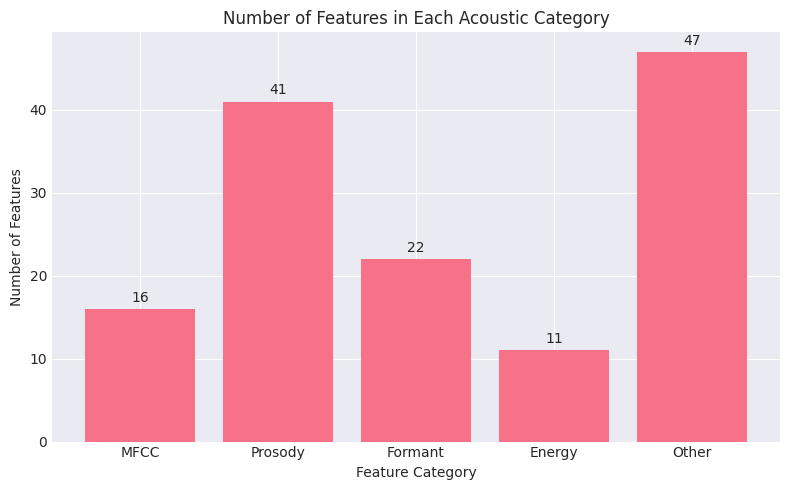


Using 'parkinsons' as Parkinsons condition column.

✓ Merged dataset shape (with Parkinson labels): (4879, 137)
  - Recordings: 4879

Parkinsons vs Control counts:
pd_label_name
Parkinsons    2441
Control       2438
Name: count, dtype: int64

=== MFCC features: 16 total ===

Top 10 most differentiating features in this category (by |Cohen's d|):


,feature,mean_control,mean_parkinsons,cohens_d,abs_d
6,mfcc4_sma3_amean,5.289776,7.360697,0.250776,0.250776
14,mfcc4V_sma3nz_amean,1.905611,4.556881,0.219869,0.219869
0,mfcc1_sma3_amean,19.437382,18.038818,-0.176625,0.176625
10,mfcc2V_sma3nz_amean,6.468620,8.242568,0.151004,0.151004
8,mfcc1V_sma3nz_amean,24.142801,22.684082,-0.109157,0.109157
2,mfcc2_sma3_amean,8.481922,9.360665,0.105762,0.105762
15,mfcc4V_sma3nz_stddevNorm,-3.459629,1.983982,0.050401,0.050401
5,mfcc3_sma3_stddevNorm,-1.029690,0.789853,0.046432,0.046432
4,mfcc3_sma3_amean,9.079203,8.648616,-0.044355,0.044355
11,mfcc2V_sma3nz_stddevNorm,-1.008084,0.275960,0.041050,0.041050


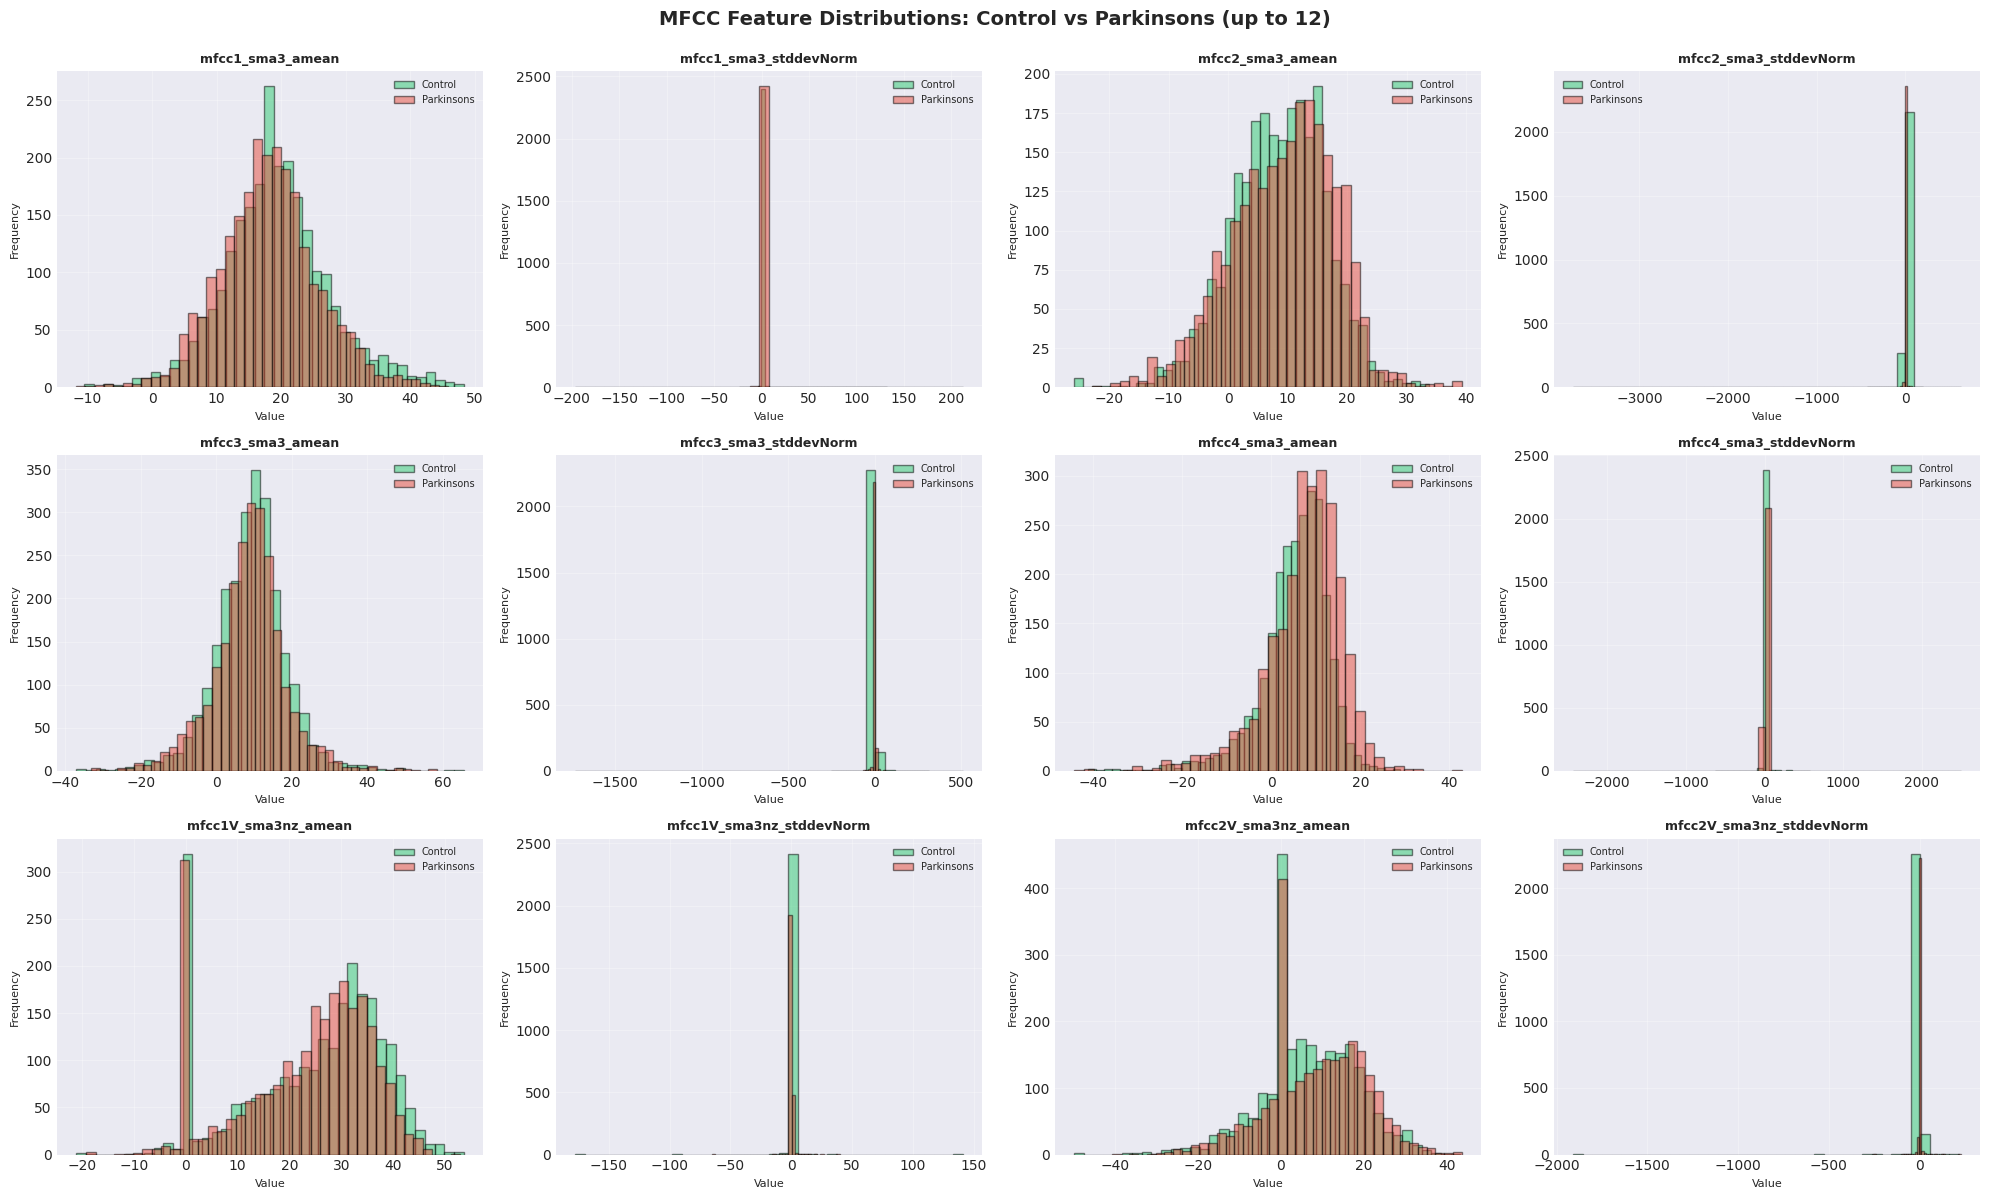


=== Prosody features: 41 total ===

Top 10 most differentiating features in this category (by |Cohen's d|):


,feature,mean_control,mean_parkinsons,cohens_d,abs_d
20,F1amplitudeLogRelF0_sma3nz_amean,-136.477787,-146.434776,-0.193270,0.193270
22,F2amplitudeLogRelF0_sma3nz_amean,-138.233676,-147.269773,-0.182340,0.182340
27,std_f0_hertz,35.678370,41.636607,0.180491,0.180491
24,F3amplitudeLogRelF0_sma3nz_amean,-140.501932,-149.010257,-0.179207,0.179207
7,F0semitoneFrom27.5Hz_sma3nz_stddevRisingSlope,115.037192,148.807996,0.173210,0.173210
10,jitterLocal_sma3nz_amean,0.019517,0.022596,0.154811,0.154811
6,F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope,128.436242,159.202465,0.138703,0.138703
3,F0semitoneFrom27.5Hz_sma3nz_percentile50.0,24.365484,25.837814,0.119855,0.119855
9,F0semitoneFrom27.5Hz_sma3nz_stddevFallingSlope,39.348871,50.942055,0.118737,0.118737
2,F0semitoneFrom27.5Hz_sma3nz_percentile20.0,22.352156,23.631933,0.114173,0.114173


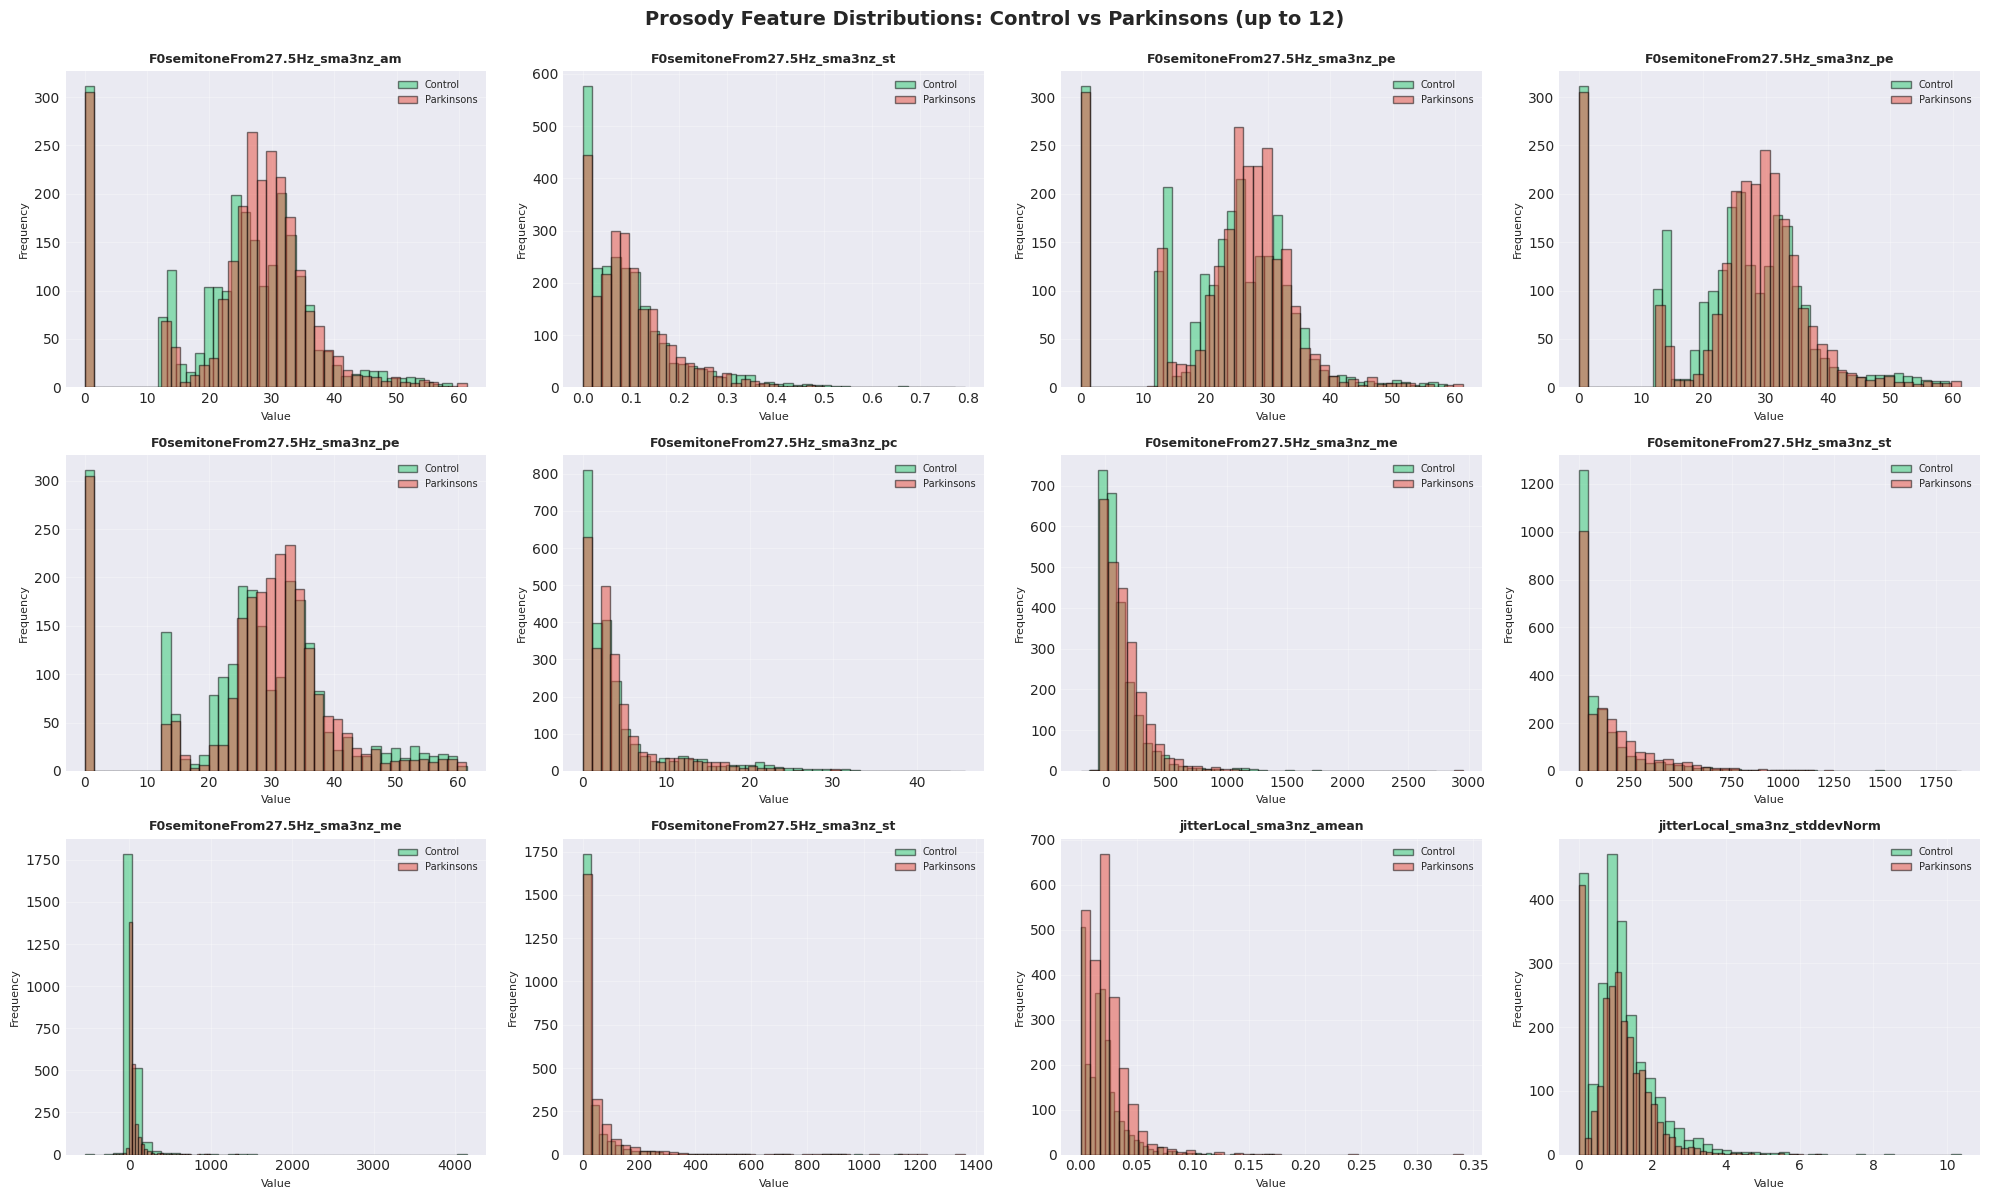


=== Formant features: 22 total ===

Top 10 most differentiating features in this category (by |Cohen's d|):


,feature,mean_control,mean_parkinsons,cohens_d,abs_d
19,std_f1_loc,202.375751,237.918610,0.305386,0.305386
4,F1amplitudeLogRelF0_sma3nz_amean,-136.477787,-146.434776,-0.193270,0.193270
10,F2amplitudeLogRelF0_sma3nz_amean,-138.233676,-147.269773,-0.182340,0.182340
16,F3amplitudeLogRelF0_sma3nz_amean,-140.501932,-149.010257,-0.179207,0.179207
11,F2amplitudeLogRelF0_sma3nz_stddevNorm,-0.580869,-0.524852,0.113709,0.113709
1,F1frequency_sma3nz_stddevNorm,0.257120,0.270291,0.097721,0.097721
3,F1bandwidth_sma3nz_stddevNorm,0.130944,0.137411,0.091512,0.091512
17,F3amplitudeLogRelF0_sma3nz_stddevNorm,-0.509544,-0.480055,0.082444,0.082444
5,F1amplitudeLogRelF0_sma3nz_stddevNorm,-0.695711,-0.573715,0.068020,0.068020
15,F3bandwidth_sma3nz_stddevNorm,0.256519,0.265246,0.063345,0.063345


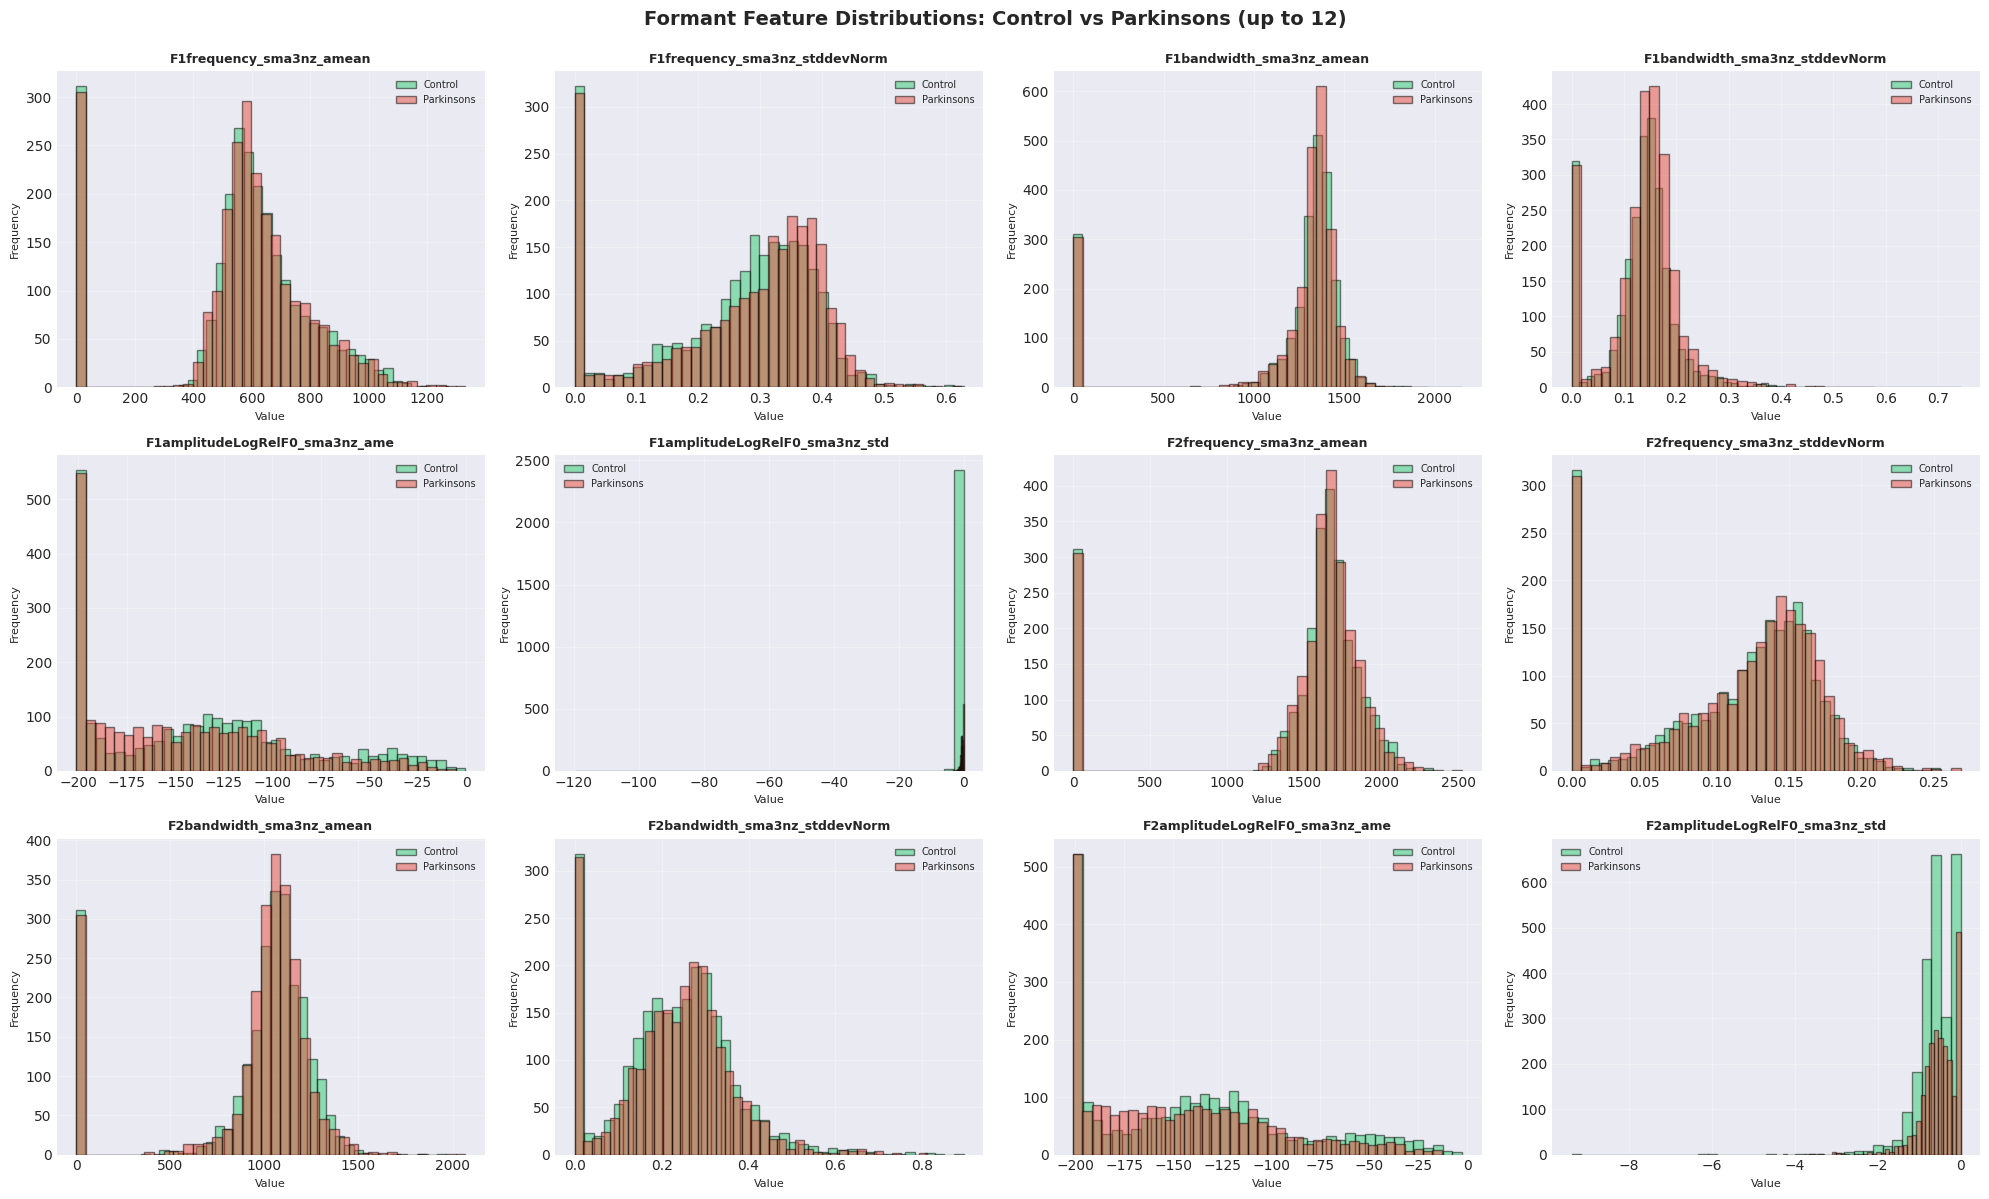


=== Energy features: 11 total ===

Top 10 most differentiating features in this category (by |Cohen's d|):


,feature,mean_control,mean_parkinsons,cohens_d,abs_d
9,loudness_sma3_stddevFallingSlope,3.020739,5.329740,0.416871,0.416871
7,loudness_sma3_stddevRisingSlope,3.862409,6.095141,0.362847,0.362847
8,loudness_sma3_meanFallingSlope,4.714226,7.008379,0.311871,0.311871
0,loudness_sma3_amean,0.403582,0.534728,0.297824,0.297824
6,loudness_sma3_meanRisingSlope,6.089597,8.428269,0.267469,0.267469
4,loudness_sma3_percentile80.0,0.642524,0.864181,0.260457,0.260457
5,loudness_sma3_pctlrange0-2,0.504742,0.699223,0.241295,0.241295
3,loudness_sma3_percentile50.0,0.285849,0.359807,0.201108,0.201108
10,loudnessPeaksPerSec,2.102368,1.880773,-0.150288,0.150288
2,loudness_sma3_percentile20.0,0.137781,0.164957,0.120842,0.120842


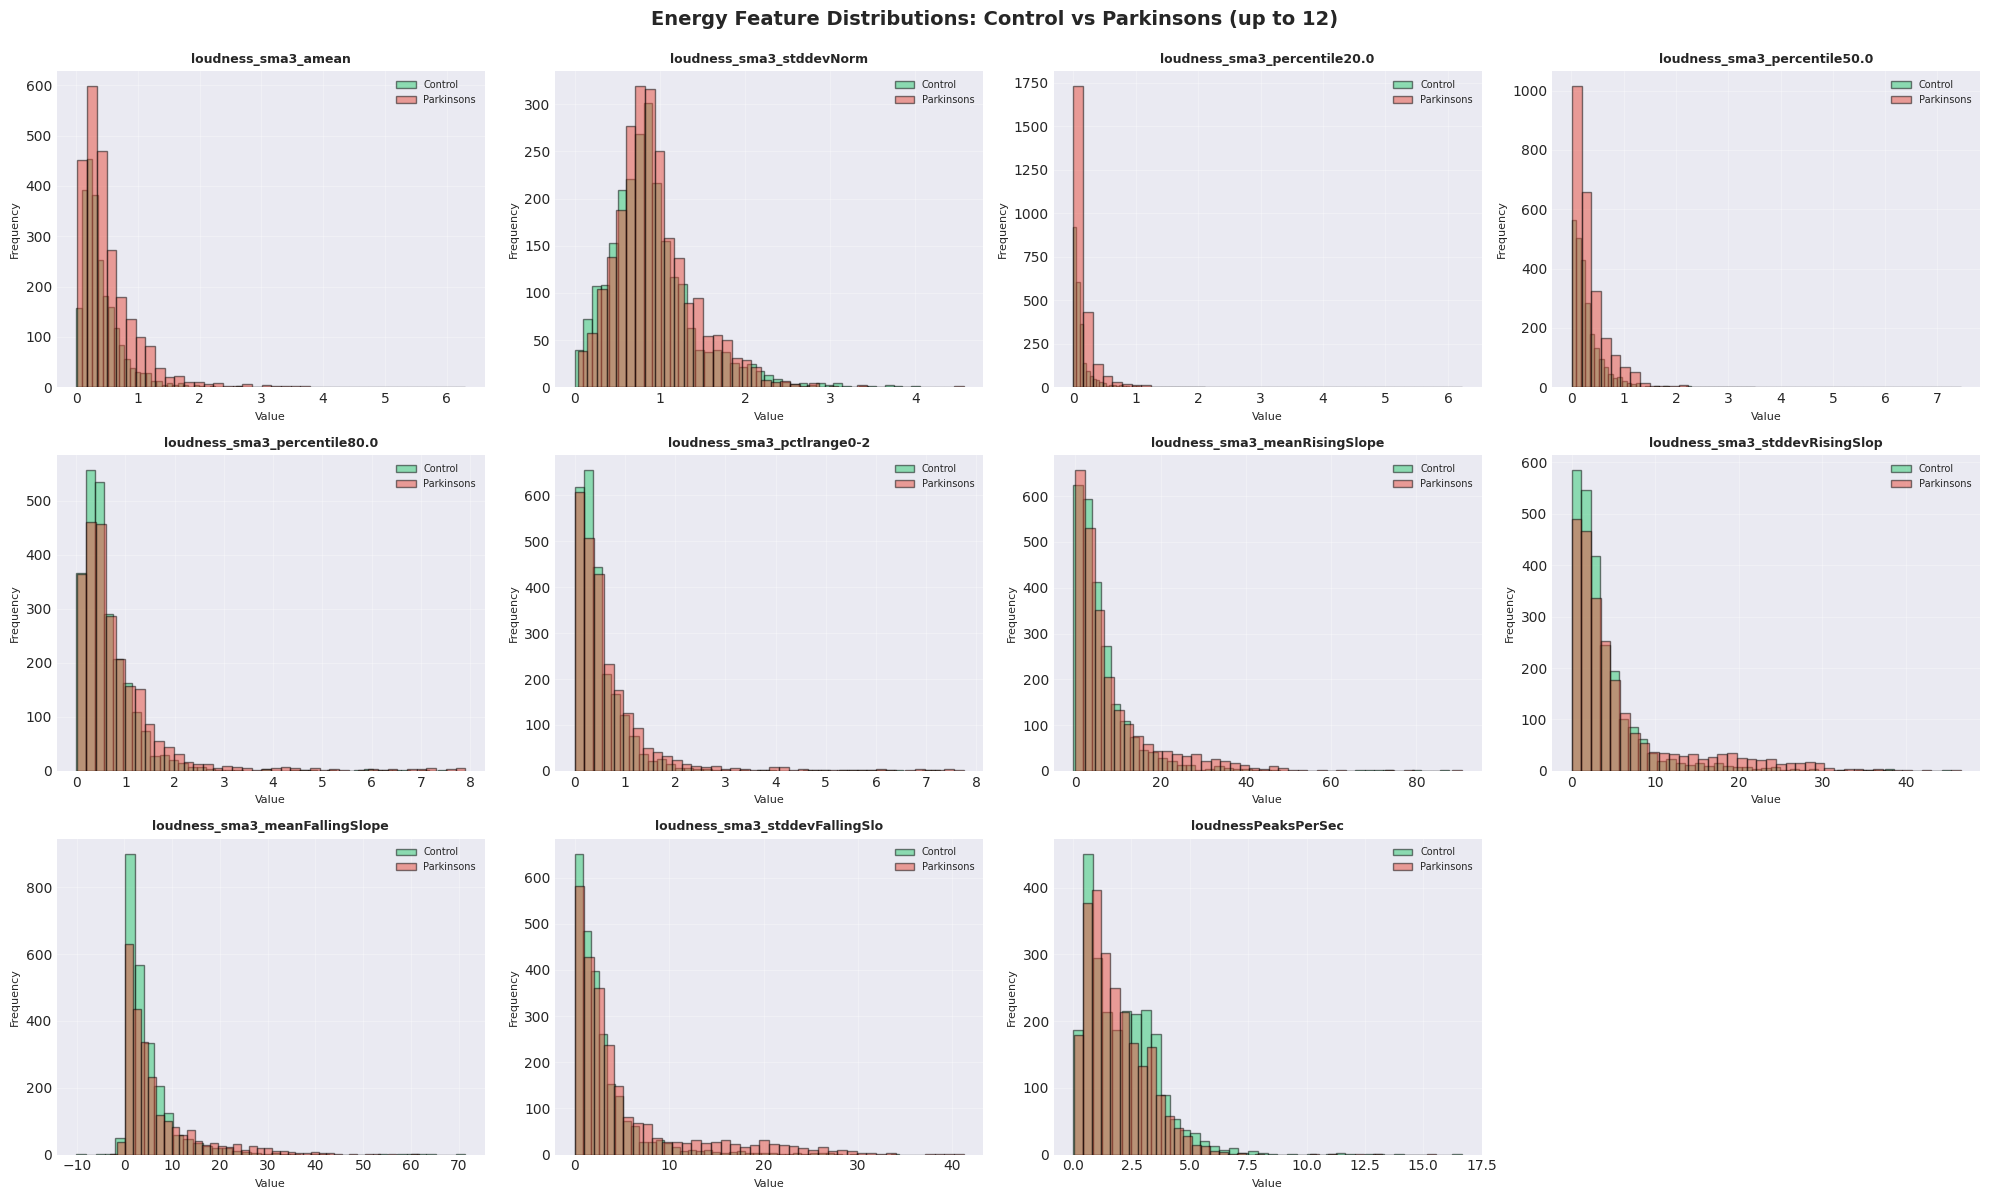


=== Other features: 47 total ===

Top 10 most differentiating features in this category (by |Cohen's d|):


,feature,mean_control,mean_parkinsons,cohens_d,abs_d
0,spectralFlux_sma3_amean,0.180008,0.320040,0.419623,0.419623
16,spectralFluxUV_sma3nz_amean,0.141710,0.262442,0.368377,0.368377
10,spectralFluxV_sma3nz_amean,0.266161,0.471386,0.364234,0.364234
22,equivalentSoundLevel_dBp,-30.367782,-26.934178,0.335325,0.335325
14,slopeUV0-500_sma3nz_amean,-0.024412,-0.030788,-0.268122,0.268122
34,cepstral_peak_prominence_mean,10.128568,9.250592,-0.244793,0.244793
29,mean_intensity_db,62.413691,66.704209,0.243229,0.243229
26,phonation_ratio,0.872156,0.819012,-0.243076,0.243076
45,pesq,2.367212,2.118426,-0.237712,0.237712
18,MeanVoicedSegmentLengthSec,1.314479,0.669520,-0.193437,0.193437


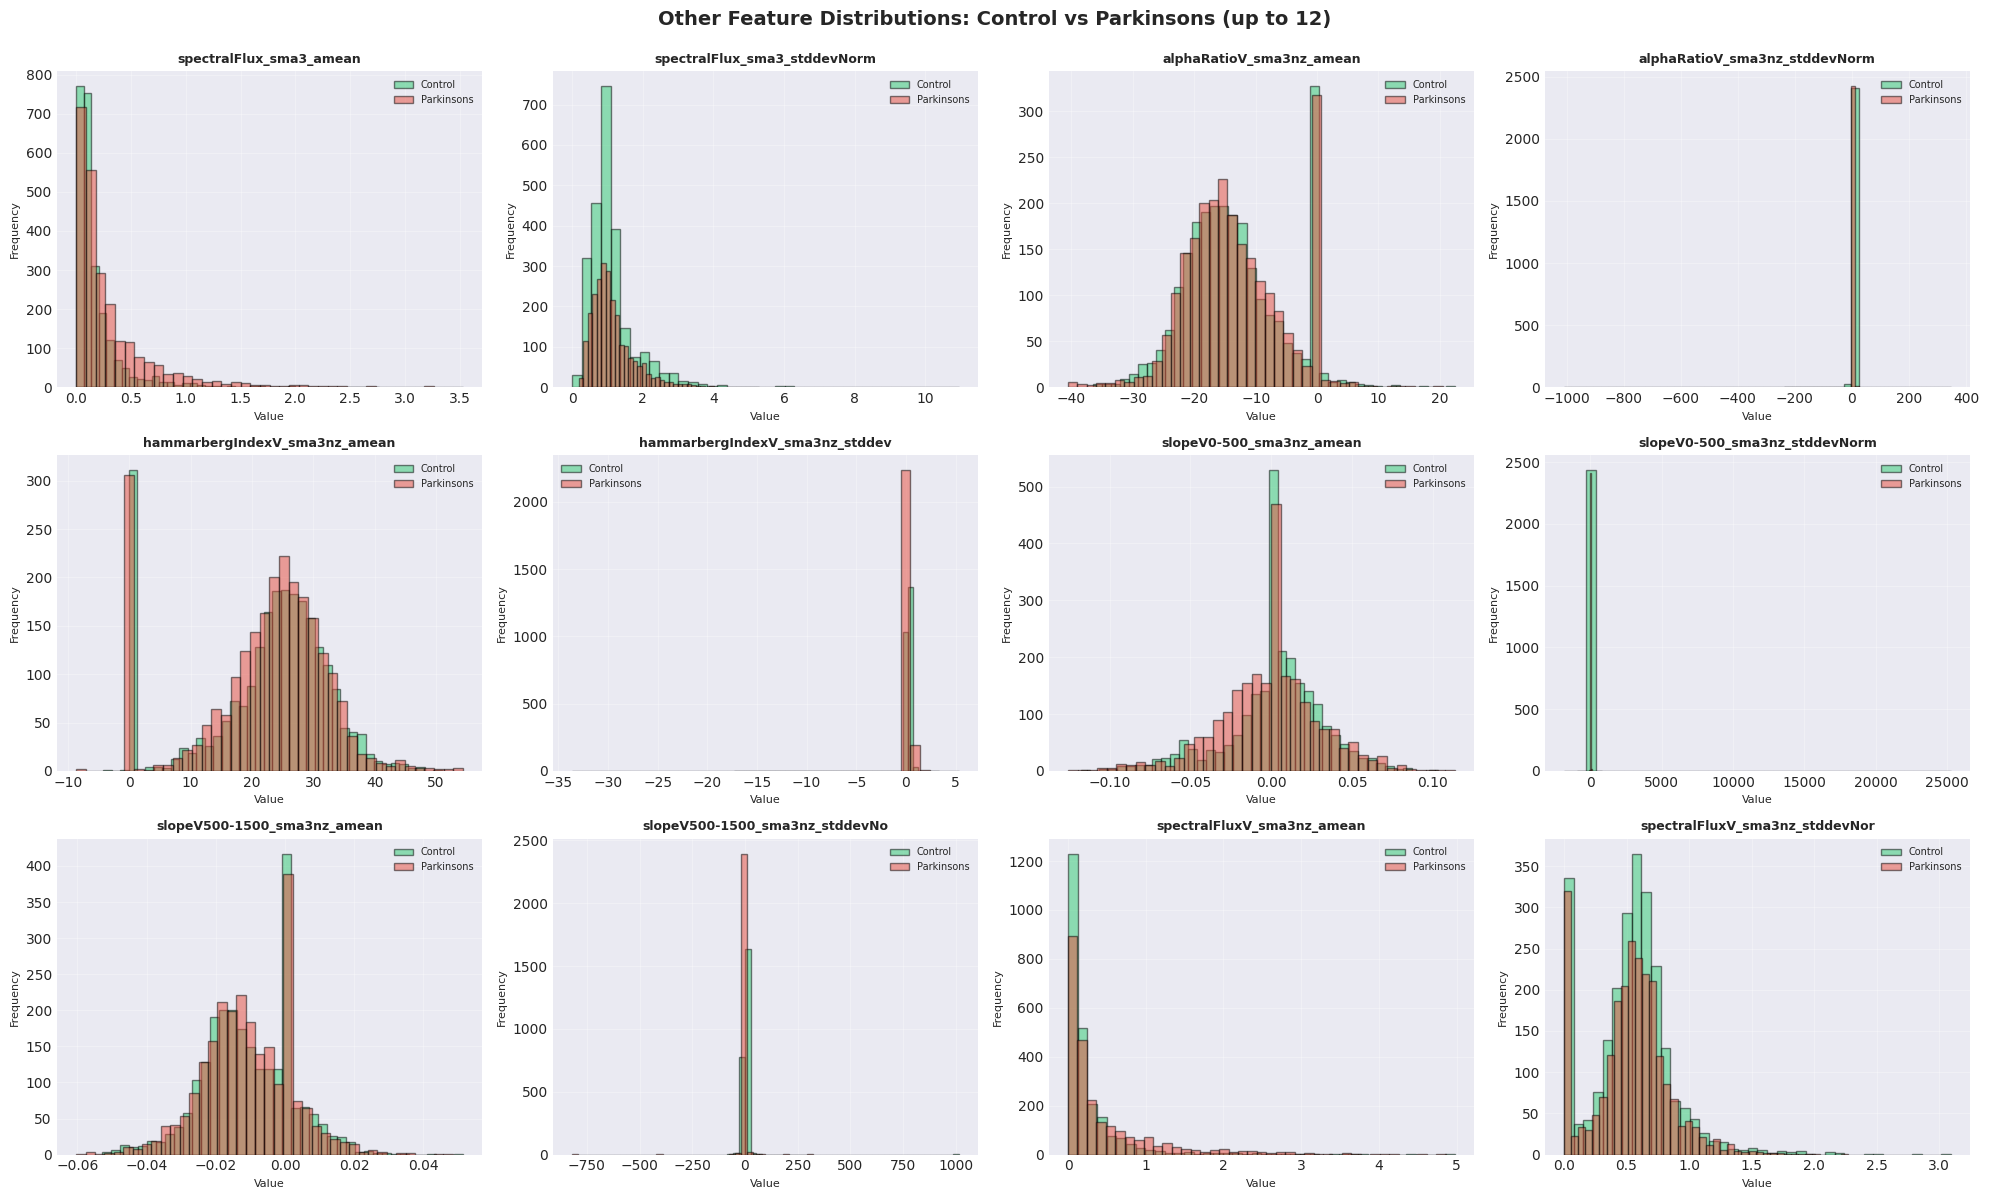

In [27]:
# 7. Static Acoustic Features Analysis (Parkinsons vs Controls)
print("=" * 60)
print("7. STATIC ACOUSTIC FEATURES ANALYSIS (Parkinsons vs Controls)")
print("=" * 60)

if STATIC_FILE.exists():
    static_df = pd.read_csv(STATIC_FILE, sep='\t', low_memory=False)
    print(f"✓ Static features shape: {static_df.shape}")
    print(f"  - Recordings: {static_df.shape[0]}")
    print(f"  - Features: {static_df.shape[1]}")
    
    # Identify feature types
    numeric_cols = static_df.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = static_df.select_dtypes(include=['object']).columns.tolist()
    id_cols = ['participant_id', 'session_id', 'task_name', 'transcription']
    
    feature_cols = [c for c in numeric_cols if c not in id_cols]
    print(f"\nFeature breakdown:")
    print(f"  - Numeric features (used for modeling): {len(feature_cols)}")
    print(f"  - Categorical columns: {len([c for c in categorical_cols if c not in id_cols])}")
    print(f"  - ID/metadata columns: {len([c for c in id_cols if c in static_df.columns])}")
    
    # Feature categories
    mfcc_features = [f for f in feature_cols if 'mfcc' in f.lower()]
    prosody_features = [f for f in feature_cols if any(x in f.lower() for x in ['f0', 'pitch', 'jitter', 'shimmer', 'hnr'])]
    formant_features = [f for f in feature_cols if any(x in f.lower() for x in ['f1', 'f2', 'f3', 'formant'])]
    energy_features = [f for f in feature_cols if 'energy' in f.lower() or 'loudness' in f.lower()]
    other_features = [f for f in feature_cols if f not in mfcc_features + prosody_features + formant_features + energy_features]
    
    print(f"\nFeature categories:")
    print(f"  - MFCC features: {len(mfcc_features)}")
    print(f"  - Prosody features (F0, jitter, shimmer, etc.): {len(prosody_features)}")
    print(f"  - Formant features (F1, F2, F3, 'formant'): {len(formant_features)}")
    print(f"  - Energy features: {len(energy_features)}")
    print(f"  - Other features: {len(other_features)}")
    
    # ==============================
    # 7a. Category size bar chart
    # ==============================
    category_names = ["MFCC", "Prosody", "Formant", "Energy", "Other"]
    category_counts = [
        len(mfcc_features),
        len(prosody_features),
        len(formant_features),
        len(energy_features),
        len(other_features),
    ]
    
    plt.figure(figsize=(8, 5))
    plt.bar(category_names, category_counts)
    plt.xlabel("Feature Category")
    plt.ylabel("Number of Features")
    plt.title("Number of Features in Each Acoustic Category")
    for i, v in enumerate(category_counts):
        plt.text(i, v + 0.5, str(v), ha='center', va='bottom', fontsize=10)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "feature_category_counts.png", dpi=300, bbox_inches="tight")
    plt.show()
    
    # ==============================
    # Merge with phenotype labels
    # ==============================
    merge_cols = ['participant_id', 'session_id']
    if 'task_name' in phenotype_df.columns:
        merge_cols_with_task = merge_cols + ['task_name']
    else:
        merge_cols_with_task = merge_cols
    
    # --- find Parkinsons condition column (case-insensitive) ---
    pd_cond_candidates = [c for c in phenotype_df.columns if 'parkinson' in c.lower()]
    if not pd_cond_candidates:
        raise ValueError("Could not find a Parkinsons column in phenotype_df (no column name contains 'parkinson').")
    pd_cond_col = pd_cond_candidates[0]
    print(f"\nUsing '{pd_cond_col}' as Parkinsons condition column.")
    
    # create Parkinsons-vs-Control labels in phenotype_df
    phenotype_df['pd_label'] = (
        phenotype_df[pd_cond_col].astype(str).str.lower() == 'checked'
    ).astype(int)
    phenotype_df['pd_label_name'] = phenotype_df['pd_label'].map({0: 'Control', 1: 'Parkinsons'})
    
    phenotype_cols_for_merge = merge_cols_with_task + ['pd_label', 'pd_label_name']
    
    merged_df = static_df.merge(
        phenotype_df[phenotype_cols_for_merge],
        on=merge_cols_with_task,
        how='left'
    )
    merged_df = merged_df.dropna(subset=['pd_label'])
    merged_df['pd_label'] = merged_df['pd_label'].astype(int)
    
    print(f"\n✓ Merged dataset shape (with Parkinson labels): {merged_df.shape}")
    print(f"  - Recordings: {len(merged_df)}")
    
    print("\nParkinsons vs Control counts:")
    print(merged_df['pd_label_name'].value_counts())
    
    # ==============================
    # Helper: effect size (Cohen's d)
    # ==============================
    def compute_effect_sizes(df, feature_list, label_col='pd_label'):
        """
        Returns a DataFrame with Cohen's d between label 0 and 1 for each feature.
        Positive d => higher in label==1 (Parkinsons),
        Negative d => higher in label==0 (Control).
        """
        rows = []
        g0 = df[df[label_col] == 0]
        g1 = df[df[label_col] == 1]
        
        for feat in feature_list:
            if feat not in df.columns:
                continue
            x0 = g0[feat].dropna()
            x1 = g1[feat].dropna()
            if len(x0) < 10 or len(x1) < 10:
                continue  # skip very sparse
            
            m0, m1 = x0.mean(), x1.mean()
            s0, s1 = x0.std(ddof=1), x1.std(ddof=1)
            n0, n1 = len(x0), len(x1)
            sp = np.sqrt(((n0 - 1)*s0**2 + (n1 - 1)*s1**2) / (n0 + n1 - 2))
            if sp == 0 or np.isnan(sp):
                continue
            
            d = (m1 - m0) / sp
            rows.append({
                "feature": feat,
                "mean_control": m0,
                "mean_parkinsons": m1,
                "cohens_d": d,
                "abs_d": abs(d)
            })
        
        if not rows:
            return pd.DataFrame()
        return pd.DataFrame(rows).sort_values("abs_d", ascending=False)
    
    # ==============================
    # Helper: per-category plots by PD label
    # ==============================
    def plot_feature_group_by_pd(group_name, feature_list, df, max_features=12):
        if len(feature_list) == 0:
            print(f"\n⚠ No features found for category: {group_name}")
            return
        
        label_names = ['Control', 'Parkinsons']
        colors = {'Control': '#2ecc71', 'Parkinsons': '#e74c3c'}
        
        print(f"\n=== {group_name} features: {len(feature_list)} total ===")
        
        eff_df = compute_effect_sizes(df, feature_list, label_col='pd_label')
        if not eff_df.empty:
            print("\nTop 10 most differentiating features in this category (by |Cohen's d|):")
            display(eff_df.head(10))
        else:
            print("Could not compute effect sizes for this category.")
        
        sample_feats = feature_list[:max_features]
        n_feats = len(sample_feats)
        
        n_rows, n_cols = 3, 4
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 12))
        axes = axes.flatten()
        
        for idx, feat in enumerate(sample_feats):
            ax = axes[idx]
            if feat not in df.columns:
                ax.axis("off")
                continue
            
            feat_data = df[[feat, 'pd_label_name']].dropna()
            if feat_data.empty:
                ax.set_title(f"{feat[:30]} (no data)", fontsize=9)
                ax.axis("off")
                continue
            
            for lab_name in label_names:
                vals = feat_data[feat_data['pd_label_name'] == lab_name][feat]
                if len(vals) == 0:
                    continue
                ax.hist(
                    vals,
                    bins=40,
                    alpha=0.5,
                    edgecolor='black',
                    label=lab_name,
                    density=False,
                    color=colors[lab_name]
                )
            
            ax.set_title(feat[:30], fontsize=9, fontweight="bold")
            ax.set_xlabel("Value", fontsize=8)
            ax.set_ylabel("Frequency", fontsize=8)
            ax.grid(alpha=0.3)
            ax.legend(fontsize=7)
        
        # Hide unused subplots
        for j in range(n_feats, len(axes)):
            axes[j].axis("off")
        
        plt.suptitle(f"{group_name} Feature Distributions: Control vs Parkinsons (up to {max_features})",
                     fontsize=14, fontweight="bold", y=0.995)
        plt.tight_layout()
        fname = f"static_features_{group_name.lower().replace(' ', '_')}_pd.png"
        plt.savefig(OUTPUT_DIR / fname, dpi=300, bbox_inches="tight")
        plt.show()
    
    # ==============================
    # 7b. Per-category graphical analysis BY Parkinson status
    # ==============================
    plot_feature_group_by_pd("MFCC", mfcc_features, merged_df)
    plot_feature_group_by_pd("Prosody", prosody_features, merged_df)
    plot_feature_group_by_pd("Formant", formant_features, merged_df)
    plot_feature_group_by_pd("Energy", energy_features, merged_df)
    plot_feature_group_by_pd("Other", other_features, merged_df)

else:
    raise FileNotFoundError(f"static_features.tsv not found at {STATIC_FILE}")


# 8. Screening-Relevant Demographics Analysis and Feature Preparation

This section prepares demographic and lifestyle variables that would be available at screening time. These variables will be added to the feature matrix for downstream analysis.

In [28]:
# ============================================================
# Screening Demographics: Data Preparation
# ============================================================

print("=" * 60)
print("8. SCREENING DEMOGRAPHICS PREPARATION")
print("=" * 60)

# Ensure we have phenotype data
if 'phenotype_df' not in locals():
    if PHENOTYPE_FILE.exists():
        phenotype_df = pd.read_csv(PHENOTYPE_FILE, sep='\t', low_memory=False)
        print(f"✓ Loaded phenotype data: {phenotype_df.shape}")
    else:
        print("⚠ Phenotype file not found. Skipping screening demographics.")
        screening_demographics_df = None
else:
    print(f"✓ Using existing phenotype_df: {phenotype_df.shape}")

if 'phenotype_df' in locals() and phenotype_df is not None:
    # Create screening demographics dataframe
    screening_demographics_df = phenotype_df.copy()
    
    # Clean age
    if 'age' in screening_demographics_df.columns:
        def extract_age(value):
            if pd.isna(value):
                return np.nan
            value_str = str(value)
            if 'and above' in value_str.lower() or '90+' in value_str:
                return 90.0
            import re
            matches = re.findall(r'\b([1-9][0-9])\b', value_str)
            if matches:
                for match in matches:
                    age_val = float(match)
                    if 10 <= age_val <= 120:
                        return age_val
            try:
                age_val = float(value_str)
                if 10 <= age_val <= 120:
                    return age_val
            except:
                pass
            return np.nan
        
        screening_demographics_df['age_clean'] = screening_demographics_df['age'].apply(extract_age)
        screening_demographics_df['age_clean'] = pd.to_numeric(screening_demographics_df['age_clean'], errors='coerce')
    
    # Calculate BMI
    if 'weight' in screening_demographics_df.columns and 'height' in screening_demographics_df.columns:
        weight_data = pd.to_numeric(screening_demographics_df['weight'], errors='coerce')
        height_data = pd.to_numeric(screening_demographics_df['height'], errors='coerce')
        
        # Check units
        if 'unit' in screening_demographics_df.columns:
            units = screening_demographics_df['unit'].dropna().unique()
            use_metric = 'US customary units' not in str(units).lower() if len(units) > 0 else True
        else:
            use_metric = height_data.mean() > 100 if height_data.notna().any() else True
        
        # Convert to metric if needed
        if not use_metric:
            height_m = height_data * 0.0254  # inches to meters
            weight_kg = weight_data * 0.453592  # lbs to kg
        else:
            if height_data.mean() > 100:  # Likely cm
                height_m = height_data * 0.01  # cm to meters
            else:
                height_m = height_data
            weight_kg = weight_data
        
        # Calculate BMI
        bmi = weight_kg / (height_m ** 2)
        bmi = bmi[(bmi > 10) & (bmi < 60)]
        screening_demographics_df['bmi'] = np.nan
        screening_demographics_df.loc[bmi.index, 'bmi'] = bmi.values
    
    # Select screening variables to include in feature matrix
    screening_vars_to_include = {
        'age': 'age_clean' if 'age_clean' in screening_demographics_df.columns else 'age',
        'sex': 'sex_at_birth',
        'weight': 'weight',
        'height': 'height',
        'bmi': 'bmi',
        'ethnicity': 'ethnicity',
        'alcohol_yn': 'alcohol_yn',
        'alcohol_freq': 'alcohol_freq',
        'alcohol_amt': 'alcohol_amt',
        'household_count': 'household_count',
        'caffeine_intake': 'caffeine_intake',
        'caffeine_intake_today': 'caffeine_intake_today',
        'hydration': 'hydration',
        'hydration_today': 'hydration_today',
        'tired_measure': 'tired_measure',
        'country': 'country',
        'smoking_hx': 'smoking_hx',
    }
    
    # Create a subset with only screening variables
    screening_cols = []
    for var_name, col_name in screening_vars_to_include.items():
        if col_name in screening_demographics_df.columns:
            screening_cols.append(col_name)
            # Rename to have 'screening_' prefix for clarity
            screening_demographics_df[f'screening_{var_name}'] = screening_demographics_df[col_name]
    
    print(f"✓ Prepared {len(screening_cols)} screening demographic variables")
    print(f"  Variables: {list(screening_vars_to_include.keys())}")
    
    # Keep participant_id and session_id for merging
    merge_cols = ['participant_id']
    if 'session_id' in screening_demographics_df.columns:
        merge_cols.append('session_id')
    
    # Create screening demographics dataframe with merge keys and screening variables
    screening_features_df = screening_demographics_df[merge_cols + [f'screening_{v}' for v in screening_vars_to_include.keys() 
                                                                    if f'screening_{v}' in screening_demographics_df.columns]].copy()
    
    print(f"✓ Screening demographics dataframe shape: {screening_features_df.shape}")
    print(f"  Merge columns: {merge_cols}")
    print(f"  Screening features: {screening_features_df.shape[1] - len(merge_cols)}")
else:
    screening_features_df = None
    print("⚠ Screening demographics not available")


8. SCREENING DEMOGRAPHICS PREPARATION
✓ Using existing phenotype_df: (125, 1113)
✓ Prepared 17 screening demographic variables
  Variables: ['age', 'sex', 'weight', 'height', 'bmi', 'ethnicity', 'alcohol_yn', 'alcohol_freq', 'alcohol_amt', 'household_count', 'caffeine_intake', 'caffeine_intake_today', 'hydration', 'hydration_today', 'tired_measure', 'country', 'smoking_hx']
✓ Screening demographics dataframe shape: (125, 19)
  Merge columns: ['participant_id', 'session_id']
  Screening features: 17


In [29]:
# 9. Prepare Feature Matrix and Labels (Parkinsons vs Control)
print("=" * 60)
print("9. FEATURE MATRIX PREPARATION (Parkinsons vs Control)")
print("=" * 60)

if 'merged_df' not in locals():
    print("⚠ Merged dataframe not available. Please run previous cells first.")
else:
    # Merge screening demographics if available
    if 'screening_features_df' in locals() and screening_features_df is not None:
        print("Merging screening demographics into feature matrix...")
        merge_cols = ['participant_id']
        if 'session_id' in merged_df.columns and 'session_id' in screening_features_df.columns:
            merge_cols.append('session_id')
        
        # Merge screening demographics
        merged_df = merged_df.merge(
            screening_features_df,
            on=merge_cols,
            how='left'
        )
        print(f"✓ Merged screening demographics. New shape: {merged_df.shape}")
        screening_feature_count = len([c for c in merged_df.columns if c.startswith('screening_')])
        print(f"  Added {screening_feature_count} screening demographic features")
    else:
        print("⚠ Screening demographics not available, proceeding without them")
    
    exclude_cols = [
        'participant_id', 'session_id', 'task_name', 'transcription',
        'label', 'label_name',  # in case they exist
        'pd_label', 'pd_label_name'
    ]
    feature_cols = [c for c in merged_df.columns if c not in exclude_cols]

    X = merged_df[feature_cols].copy()
    y = merged_df['pd_label'].astype(int)   # ← use Parkinson label

    print(f"✓ Initial feature matrix shape: {X.shape}")

    # Fill missing values
    missing_before = X.isna().sum().sum()
    for col in X.columns:
        if X[col].dtype in [np.float64, np.int64, np.float32]:
            X[col].fillna(X[col].median(), inplace=True)
        else:
            mode_val = X[col].mode()
            if len(mode_val) > 0:
                X[col].fillna(mode_val.iloc[0], inplace=True)
            else:
                X[col].fillna('unknown', inplace=True)
    missing_after = X.isna().sum().sum()
    print(f"✓ Missing values: {missing_before} → {missing_after}")

    # Handle infinite values
    inf_before = np.isinf(X.select_dtypes(include=[np.number])).sum().sum()
    X = X.replace([np.inf, -np.inf], np.nan)
    for col in X.select_dtypes(include=[np.number]).columns:
        X[col].fillna(X[col].median(), inplace=True)
    inf_after = np.isinf(X.select_dtypes(include=[np.number])).sum().sum()
    print(f"✓ Infinite values: {inf_before} → {inf_after}")

    print(f"\n✓ Final feature matrix shape: {X.shape}")
    print(f"  - Samples: {X.shape[0]}")
    print(f"  - Features: {X.shape[1]}")

    print(f"\n✓ Label distribution:")
    label_dist = y.value_counts().sort_index()
    for label_val, count in label_dist.items():
        label_name = 'Control' if label_val == 0 else 'Parkinsons'
        print(f"  - {label_name} ({label_val}): {count} ({count/len(y)*100:.1f}%)")

    numeric_features = X.select_dtypes(include=[np.number]).shape[1]
    categorical_features = X.select_dtypes(include=['object']).shape[1]
    print(f"\n✓ Feature types:")
    print(f"  - Numeric: {numeric_features}")
    print(f"  - Categorical: {categorical_features}")


9. FEATURE MATRIX PREPARATION (Parkinsons vs Control)
Merging screening demographics into feature matrix...
✓ Merged screening demographics. New shape: (4879, 154)
  Added 17 screening demographic features
✓ Initial feature matrix shape: (4879, 148)
✓ Missing values: 19576 → 9758
✓ Infinite values: 0 → 0

✓ Final feature matrix shape: (4879, 148)
  - Samples: 4879
  - Features: 148

✓ Label distribution:
  - Control (0): 2438 (50.0%)
  - Parkinsons (1): 2441 (50.0%)

✓ Feature types:
  - Numeric: 142
  - Categorical: 6


In [30]:
# 10. Save Processed Outputs (Standardized)
print("=" * 60)
print("10. SAVE PROCESSED OUTPUTS")
print("=" * 60)

if 'X' not in locals() or 'y' not in locals() or 'merged_df' not in locals():
    print("⚠ Required variables (X, y, merged_df) not available. Please run previous cells first.")
else:
    # Standardized output paths (following VAE_v9 pattern)
    stamp = datetime.now().strftime('%Y%m%d-%H%M%S')
    features_path = OUTPUT_DIR / f'features_parkinsons_{stamp}.csv'
    labels_path = OUTPUT_DIR / f'labels_parkinsons_{stamp}.csv'
    metadata_path = OUTPUT_DIR / f'metadata_parkinsons_{stamp}.csv'
    summary_path = OUTPUT_DIR / f'eda_summary_{stamp}.json'

    # -------------------
    # 1) Save features / labels
    # -------------------
    X.to_csv(features_path, index=False)
    print(f"✓ Features saved: {features_path}")

    # y is already your pd_label vector
    y.to_frame('pd_label').to_csv(labels_path, index=False)
    print(f"✓ Labels saved: {labels_path}")

    # -------------------
    # 2) Save metadata with correct label columns
    # -------------------
    # base metadata columns present in merged_df
    metadata_cols = ['participant_id', 'session_id']
    if 'task_name' in merged_df.columns:
        metadata_cols.append('task_name')

    # add the label fields actually present
    if all(c in merged_df.columns for c in ['pd_label', 'pd_label_name']):
        metadata_cols.extend(['pd_label', 'pd_label_name'])
    elif all(c in merged_df.columns for c in ['label', 'label_name']):
        # fallback if you're still using generic label
        metadata_cols.extend(['label', 'label_name'])
    else:
        print("⚠ No label columns found in merged_df for metadata; saving IDs only.")

    merged_df[metadata_cols].to_csv(metadata_path, index=False)
    print(f"✓ Metadata saved: {metadata_path}")

    # -------------------
    # 3) Create comprehensive summary
    # -------------------
    # Here we assume y is 0=Control, 1=Parkinsons
    n_control = int((y == 0).sum())
    n_pd = int((y == 1).sum())
    pct_control = float(n_control / len(y) * 100)
    pct_pd = float(n_pd / len(y) * 100)

    summary = {
        'timestamp': stamp,
        'dataset_info': {
            'samples': int(len(X)),
            'features': int(len(feature_cols)),
            'numeric_features': int(numeric_features),
            'categorical_features': int(categorical_features)
        },
        'label_distribution': {
            'Control': n_control,
            'Parkinsons': n_pd,
            'Control_percentage': pct_control,
            'Parkinsons_percentage': pct_pd
        },
        'feature_categories': {
            'mfcc_features': len(mfcc_features) if 'mfcc_features' in locals() else 0,
            'prosody_features': len(prosody_features) if 'prosody_features' in locals() else 0,
            'formant_features': len(formant_features) if 'formant_features' in locals() else 0,
            'energy_features': len(energy_features) if 'energy_features' in locals() else 0,
            'other_features': len(other_features) if 'other_features' in locals() else 0
        },
        'tasks': {
            'unique_tasks': int(len(task_counts)) if 'task_counts' in locals() and len(task_counts) > 0 else 0,
            'total_recordings': int(task_counts.sum()) if 'task_counts' in locals() and len(task_counts) > 0 else 0
        },
        'data_quality': {
            'missing_values_filled': int(missing_before) if 'missing_before' in locals() else 0,
            'infinite_values_filled': int(inf_before) if 'inf_before' in locals() else 0
        },
        'output_files': {
            'features': str(features_path),
            'labels': str(labels_path),
            'metadata': str(metadata_path)
        }
    }

    # Save summary
    with open(summary_path, 'w') as f:
        json.dump(summary, f, indent=2)
    print(f"✓ Summary saved: {summary_path}")

    # -------------------
    # 4) Human-readable recap
    # -------------------
    print(f"\n{'='*60}")
    print("EDA COMPLETE - Summary (Parkinsons vs Control)")
    print(f"{'='*60}")
    print(f"Samples: {summary['dataset_info']['samples']}")
    print(f"Features: {summary['dataset_info']['features']}")
    print(f"Control: {summary['label_distribution']['Control']} "
          f"({summary['label_distribution']['Control_percentage']:.1f}%)")
    print(f"Parkinsons: {summary['label_distribution']['Parkinsons']} "
          f"({summary['label_distribution']['Parkinsons_percentage']:.1f}%)")
    print(f"Unique tasks: {summary['tasks']['unique_tasks']}")
    print(f"\nAll outputs saved to: {OUTPUT_DIR}")
    print(f"{'='*60}")

    display(pd.DataFrame(
        [summary['dataset_info'], summary['label_distribution']]
    ).T)


10. SAVE PROCESSED OUTPUTS
✓ Features saved: /home/Phenotype and Voice for PD/outputs/eda_phase_2/features_parkinsons_20251217-170115.csv
✓ Labels saved: /home/Phenotype and Voice for PD/outputs/eda_phase_2/labels_parkinsons_20251217-170115.csv
✓ Metadata saved: /home/Phenotype and Voice for PD/outputs/eda_phase_2/metadata_parkinsons_20251217-170115.csv
✓ Summary saved: /home/Phenotype and Voice for PD/outputs/eda_phase_2/eda_summary_20251217-170115.json

EDA COMPLETE - Summary (Parkinsons vs Control)
Samples: 4879
Features: 148
Control: 2438 (50.0%)
Parkinsons: 2441 (50.0%)
Unique tasks: 53

All outputs saved to: /home/Phenotype and Voice for PD/outputs/eda_phase_2


,0,1
samples,4879.0,NaN
features,148.0,NaN
numeric_features,142.0,NaN
categorical_features,6.0,NaN
Control,NaN,2438.000000
Parkinsons,NaN,2441.000000
Control_percentage,NaN,49.969256
Parkinsons_percentage,NaN,50.030744


In [31]:
# ============================================================
# TASK-WISE RECORDING COUNTS (Controls vs Parkinsons)
# ============================================================

print("\n" + "="*60)
print("TASK-WISE RECORDINGS: CONTROL VS PARKINSONS")
print("="*60)

# Sanity check
if 'merged_df' not in locals():
    raise RuntimeError("merged_df not found. Run the merge step first.")

if 'pd_label' not in merged_df.columns:
    raise RuntimeError("pd_label column missing. Run the Parkinsons label creation step first.")

# pd_label: 1 = Parkinson's, 0 = Control
task_groups = merged_df.groupby('task_name')

rows = []

for task, df_task in task_groups:
    n_total = len(df_task)
    n_pd = (df_task['pd_label'] == 1).sum()
    n_ctrl = (df_task['pd_label'] == 0).sum()

    rows.append({
        "Task": task,
        "Total_Recordings": n_total,
        "Control_Recordings": n_ctrl,
        "Parkinsons_Recordings": n_pd,
        "% Parkinsons": f"{(n_pd / n_total * 100):.1f}%" if n_total > 0 else "0%"
    })

task_ct = pd.DataFrame(rows).sort_values("Total_Recordings", ascending=False)

print(f"\n✓ Tasks analyzed: {len(task_ct)}")
display(task_ct)

# ALSO: Show summary totals clearly
total_ctrl = (merged_df['pd_label'] == 0).sum()
total_pd = (merged_df['pd_label'] == 1).sum()

print("\n" + "="*60)
print("OVERALL TOTALS (ALL TASKS)")
print("="*60)
print(f"Total recordings: {len(merged_df):,}")
print(f"  - Control: {total_ctrl:,}")
print(f"  - Parkinsons: {total_pd:,}")
print(f"  - % Parkinsons: {total_pd/len(merged_df)*100:.1f}%")
print("="*60)



TASK-WISE RECORDINGS: CONTROL VS PARKINSONS

✓ Tasks analyzed: 53


,Task,Total_Recordings,Control_Recordings,Parkinsons_Recordings,% Parkinsons
1,Audio-Check-1,125,64,61,48.8%
3,Audio-Check-3,125,64,61,48.8%
2,Audio-Check-2,125,64,61,48.8%
4,Audio-Check-4,125,64,61,48.8%
17,Diadochokinesis-TA,119,60,59,49.6%
14,Diadochokinesis-KA,119,60,59,49.6%
16,Diadochokinesis-Pataka,119,60,59,49.6%
15,Diadochokinesis-PA,119,60,59,49.6%
18,Diadochokinesis-buttercup,119,60,59,49.6%
25,Loudness,119,60,59,49.6%



OVERALL TOTALS (ALL TASKS)
Total recordings: 4,879
  - Control: 2,438
  - Parkinsons: 2,441
  - % Parkinsons: 50.0%
